In [71]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [72]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [73]:
# 1) 원본 데이터
df = pp.ccf_load_data("../data/creditcard.csv")  # 원본: Time, Amount 포함

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


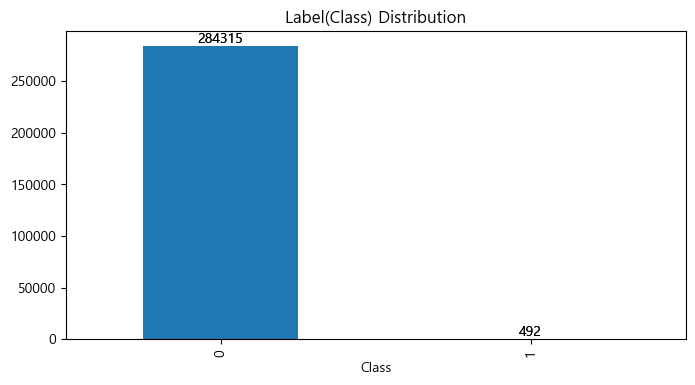

In [74]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False)

In [75]:
df.describe() # 1행이 신용카드 1건이다 # 이게 과제다. 어떤 컬럼을 어떻게 볼 것인가!

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [76]:
# 데이터가 심하게 불균형일때 일반화 성능이 떨어짐
# 이때 over sampling(큰쪽으로 작은 데이터를 만들어 늘리는 것 - 증식) => 주로 사용함. 데이터가 늘어 남
# => 늘이는 방법 : feature를 줄여서 차원을 축소(신용카드 30개 features -> 2개로 줄이고), K-NN 으로 증식 => 어쨋든 오차가 존재하게된다!
# under sampling (원래 있는 큰 데이터를 작은쪽에 맞게 줄이게) => 데이터가 줄어드니까~

In [77]:
# 2025.11.10.월. 1교시
# AutoEncoder : 생성형AI 중심 (D.L) => 데이터 생성, over sampling 데이터 증식할 때 사용, 잘 봐야한다!!! 뒤에서 다시 설명한끄야~
# M.L : KNN

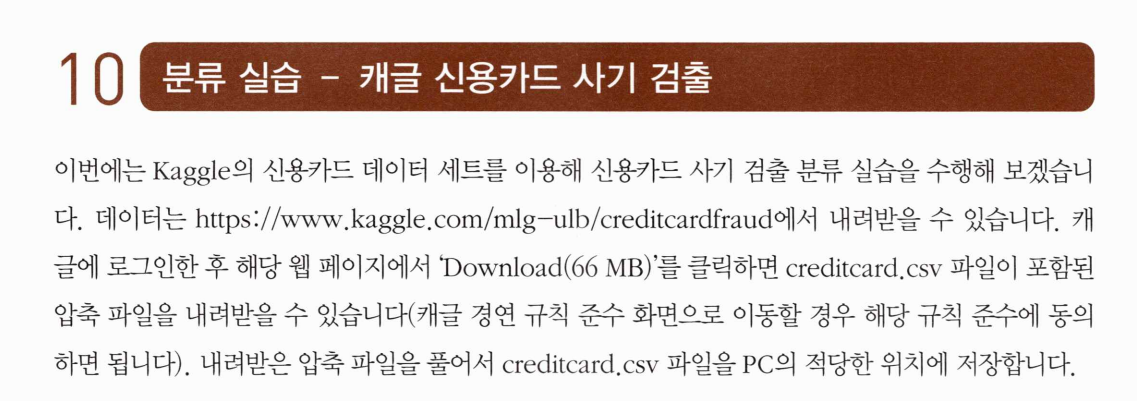
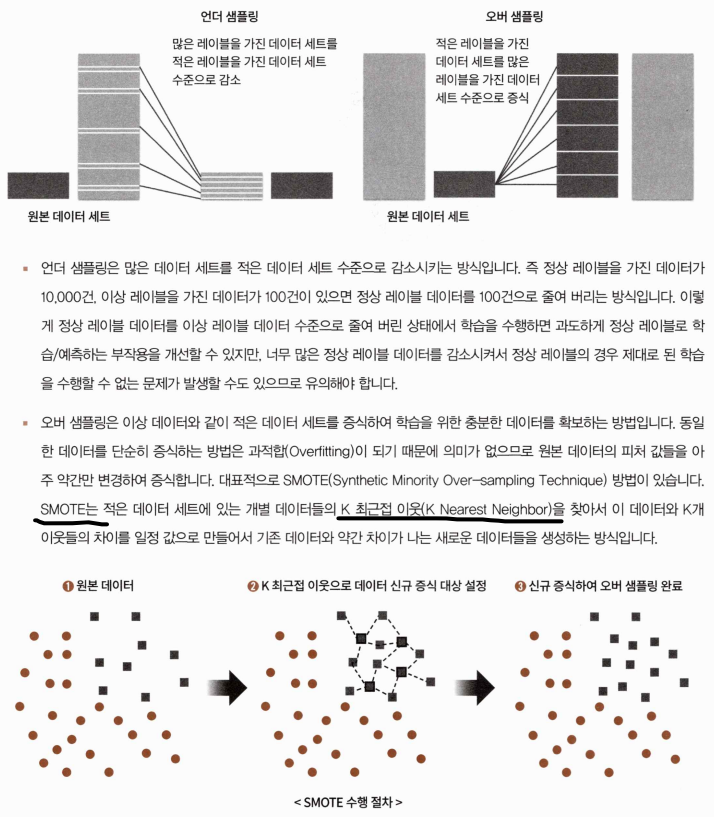

In [78]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [79]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [80]:
# RobustScaler는 이상치(극단값)에 덜 민감한 스케일링 방법
# 극단적으로 큰 결제금액 몇 개가 있어도 대부분 데이터의 스케일이 덜 왜곡
# **금액(Amount)**처럼 분포가 심하게 한쪽으로 치우치고,
# **시간(Time)**처럼 범위가 크고 이상치가 있을 수 있는 컬럼에 쓴다.

df_scaled = pp.robustScaler(df)

✅ 'Amount' 스케일링 완료 → 'Amount_scaled'
✅ 'Time' 스케일링 완료 → 'Time_scaled'

🗑️  원본 컬럼 제거: ['Amount', 'Time']

✅ 스케일링 완료: 2개 컬럼
   최종 shape: (284807, 31)


In [81]:
print(df_scaled.head())
print(df_scaled.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

# Class 비율 다시 확인 (확인 차원)
print(df_scaled['Class'].value_counts())
print(df_scaled['Class'].value_counts(normalize=True))

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  Amount_scaled  Time_scaled  

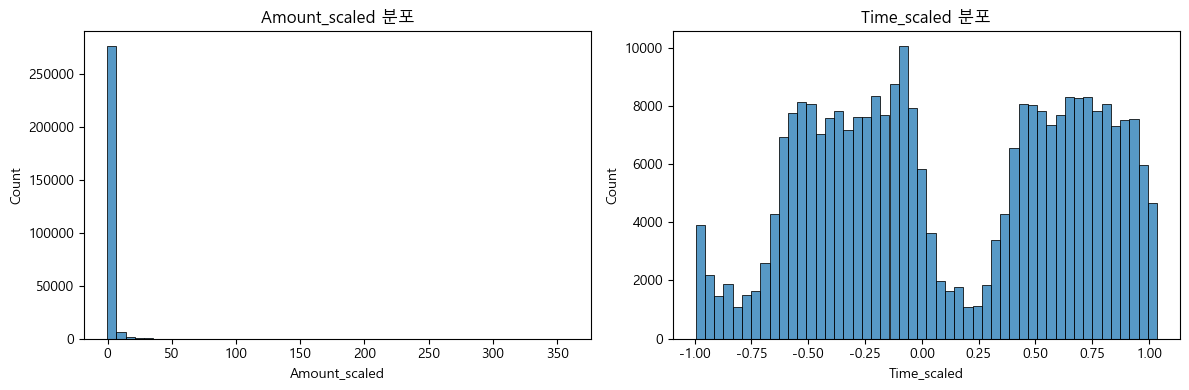

In [82]:
# Amount_scaled, Time_scaled : 해석 가능한 거의 유일한 원본 피처들

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_scaled['Amount_scaled'], bins=50)
plt.title('Amount_scaled 분포')

plt.subplot(1, 2, 2)
sns.histplot(df_scaled['Time_scaled'], bins=50)
plt.title('Time_scaled 분포')

plt.tight_layout()
plt.show()

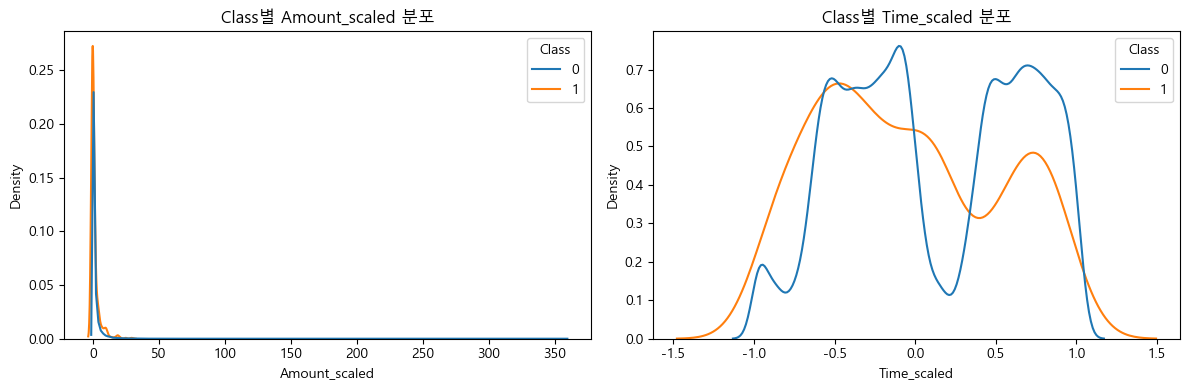

In [83]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(
    data=df_scaled,
    x='Amount_scaled',
    hue='Class',
    common_norm=False
)
plt.title('Class별 Amount_scaled 분포')

plt.subplot(1, 2, 2)
sns.kdeplot(
    data=df_scaled,
    x='Time_scaled',
    hue='Class',
    common_norm=False
)
plt.title('Class별 Time_scaled 분포')

plt.tight_layout()
plt.show()

# 시간대에 따라 사기 비율이 다를 가능성”은 있어 보임.

In [84]:
stats = df_scaled.groupby('Class')[['Amount_scaled', 'Time_scaled']].describe().T
print(stats)

Class                            0           1
Amount_scaled count  284315.000000  492.000000
              mean        0.926305    1.400284
              std         3.494796    3.586715
              min        -0.307413   -0.307413
              25%        -0.228464   -0.293440
              50%         0.000000   -0.178160
              75%         0.769231    1.172221
              max       358.683155   29.398030
Time_scaled   count  284315.000000  492.000000
              mean        0.119200   -0.046349
              std         0.557854    0.561982
              min        -0.994983   -0.990214
              25%        -0.357875   -0.510468
              50%         0.000223   -0.107185
              75%         0.641937    0.514468
              max         1.035022    1.006309


Class            1.000000
V11              0.154876
V4               0.133447
V2               0.091289
V21              0.040413
V19              0.034783
V20              0.020090
V8               0.019875
V27              0.017580
V28              0.009536
Amount_scaled    0.005632
V26              0.004455
V25              0.003308
V22              0.000805
V23             -0.002685
V15             -0.004223
V13             -0.004570
V24             -0.007221
Time_scaled     -0.012323
V6              -0.043643
V5              -0.094974
V9              -0.097733
V1              -0.101347
V18             -0.111485
V7              -0.187257
V3              -0.192961
V16             -0.196539
V10             -0.216883
V12             -0.260593
V14             -0.302544
V17             -0.326481
Name: Class, dtype: float64


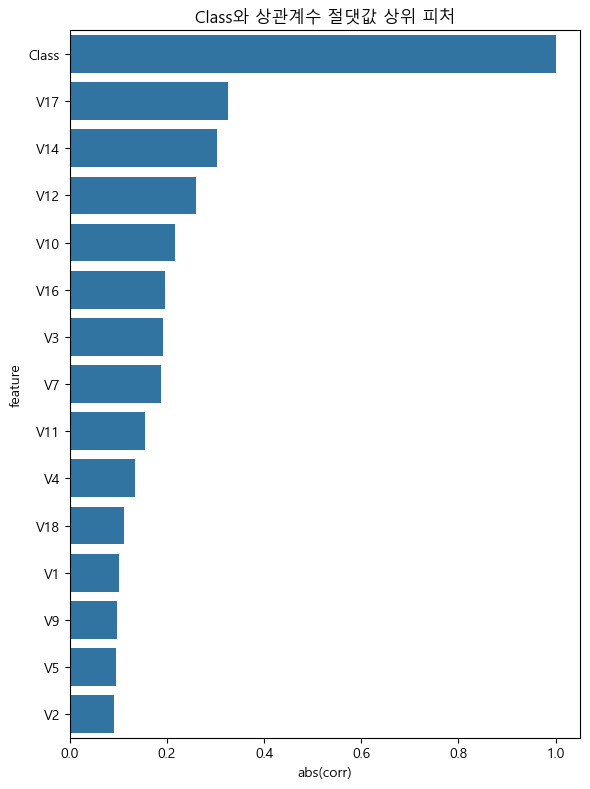

In [85]:
# 상관계수 계산
corr = df_scaled.corr()['Class'].sort_values(ascending=False)
print(corr)

# 절댓값 상위 피처만 시각화
top_corr = corr.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 8))
sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)
plt.title('Class와 상관계수 절댓값 상위 피처')
plt.xlabel('abs(corr)')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

# 이 피처들이 다른 애들보다 사기 여부와 더 강하게 연관돼 있다는 뜻
# 나중에 모델링/설명할 때 “주요 피처 후보”가 될 수 있음

In [86]:
cols_basic = ['Amount_scaled', 'Time_scaled']
df_scaled.groupby('Class')[cols_basic].describe().T

Class                            0           1
Amount_scaled count  284315.000000  492.000000
              mean        0.926305    1.400284
              std         3.494796    3.586715
              min        -0.307413   -0.307413
              25%        -0.228464   -0.293440
              50%         0.000000   -0.178160
              75%         0.769231    1.172221
              max       358.683155   29.398030
Time_scaled   count  284315.000000  492.000000
              mean        0.119200   -0.046349
              std         0.557854    0.561982
              min        -0.994983   -0.990214
              25%        -0.357875   -0.510468
              50%         0.000223   -0.107185
              75%         0.641937    0.514468
              max         1.035022    1.006309

In [87]:
# 상위 top5 피처
top_feats = ['V17', 'V14', 'V12', 'V10', 'V16']
df_scaled.groupby('Class')[top_feats].describe().T

Class                  0           1
V17 count  284315.000000  492.000000
    mean        0.011535   -6.665836
    std         0.749457    6.970618
    min       -17.098444  -25.162799
    25%        -0.482644  -11.945057
    50%        -0.064833   -5.302949
    75%         0.399922   -1.341940
    max         9.253526    6.739384
V14 count  284315.000000  492.000000
    mean        0.012064   -6.971723
    std         0.897007    4.278940
    min       -18.392091  -19.214325
    25%        -0.422453   -9.692723
    50%         0.051947   -6.729720
    75%         0.494104   -4.282821
    max        10.526766    3.442422
V12 count  284315.000000  492.000000
    mean        0.010832   -6.259393
    std         0.945939    4.654458
    min       -15.144988  -18.683715
    25%        -0.402102   -8.688177
    50%         0.141679   -5.502530
    75%         0.619207   -2.974088
    max         7.848392    1.375941
V10 count  284315.000000  492.000000
    mean        0.009824   -5.676883
    std         1.044204    4.897341
    min       -14.741096  -24.588262
    25%        -0.532880   -7.756698
    50%        -0.091872   -4.578825
    75%         0.455135   -2.614184
    max        23.745136    4.031435
V16 count  284315.000000  492.000000
    mean        0.007164   -4.139946
    std         0.844772    3.865035
    min       -10.115560  -14.129855
    25%        -0.465543   -6.562915
    50%         0.067377   -3.549795
    75%         0.523738   -1.226043
    max        17.315112    3.139656

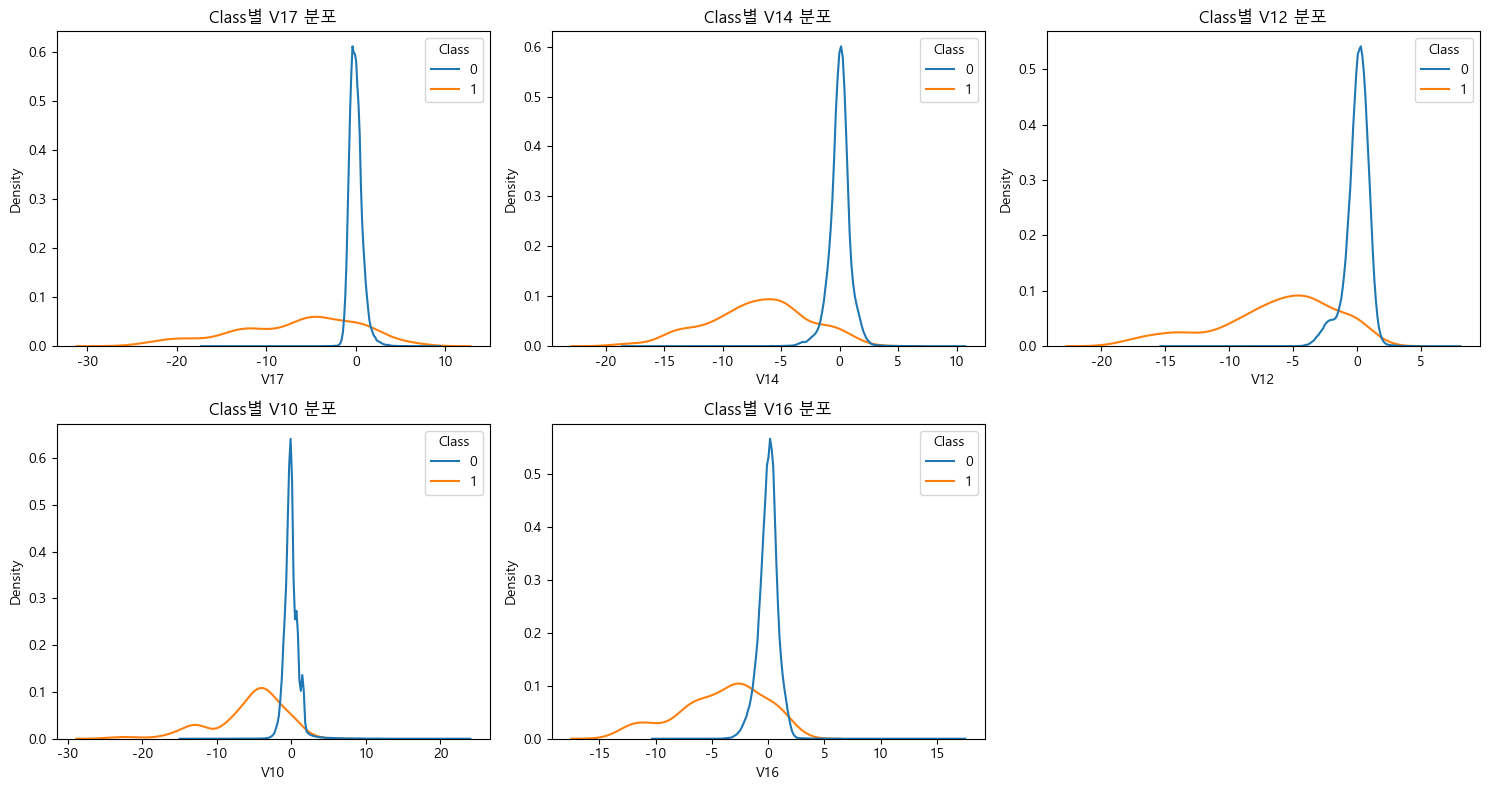

In [88]:
# 상관 상위 피처들에 대해 Class별 분포 보기

top_feats = ['V17', 'V14', 'V12', 'V10', 'V16']

plt.figure(figsize=(15, 8))
for i, col in enumerate(top_feats, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df_scaled, x=col, hue='Class', common_norm=False)
    plt.title(f'Class별 {col} 분포')
plt.tight_layout()
plt.show()


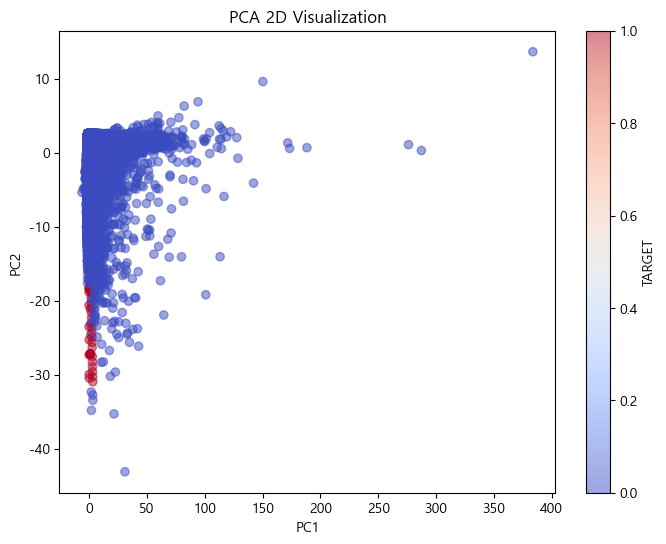

In [89]:
# PCA 2D 시각화
# 전체 피처 조합 기준으로 Class가 얼마나 섞여 있는지!

from sklearn.decomposition import PCA
from utils.evaluation import plot_pca_2d

X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plot_pca_2d(X_2d, y)


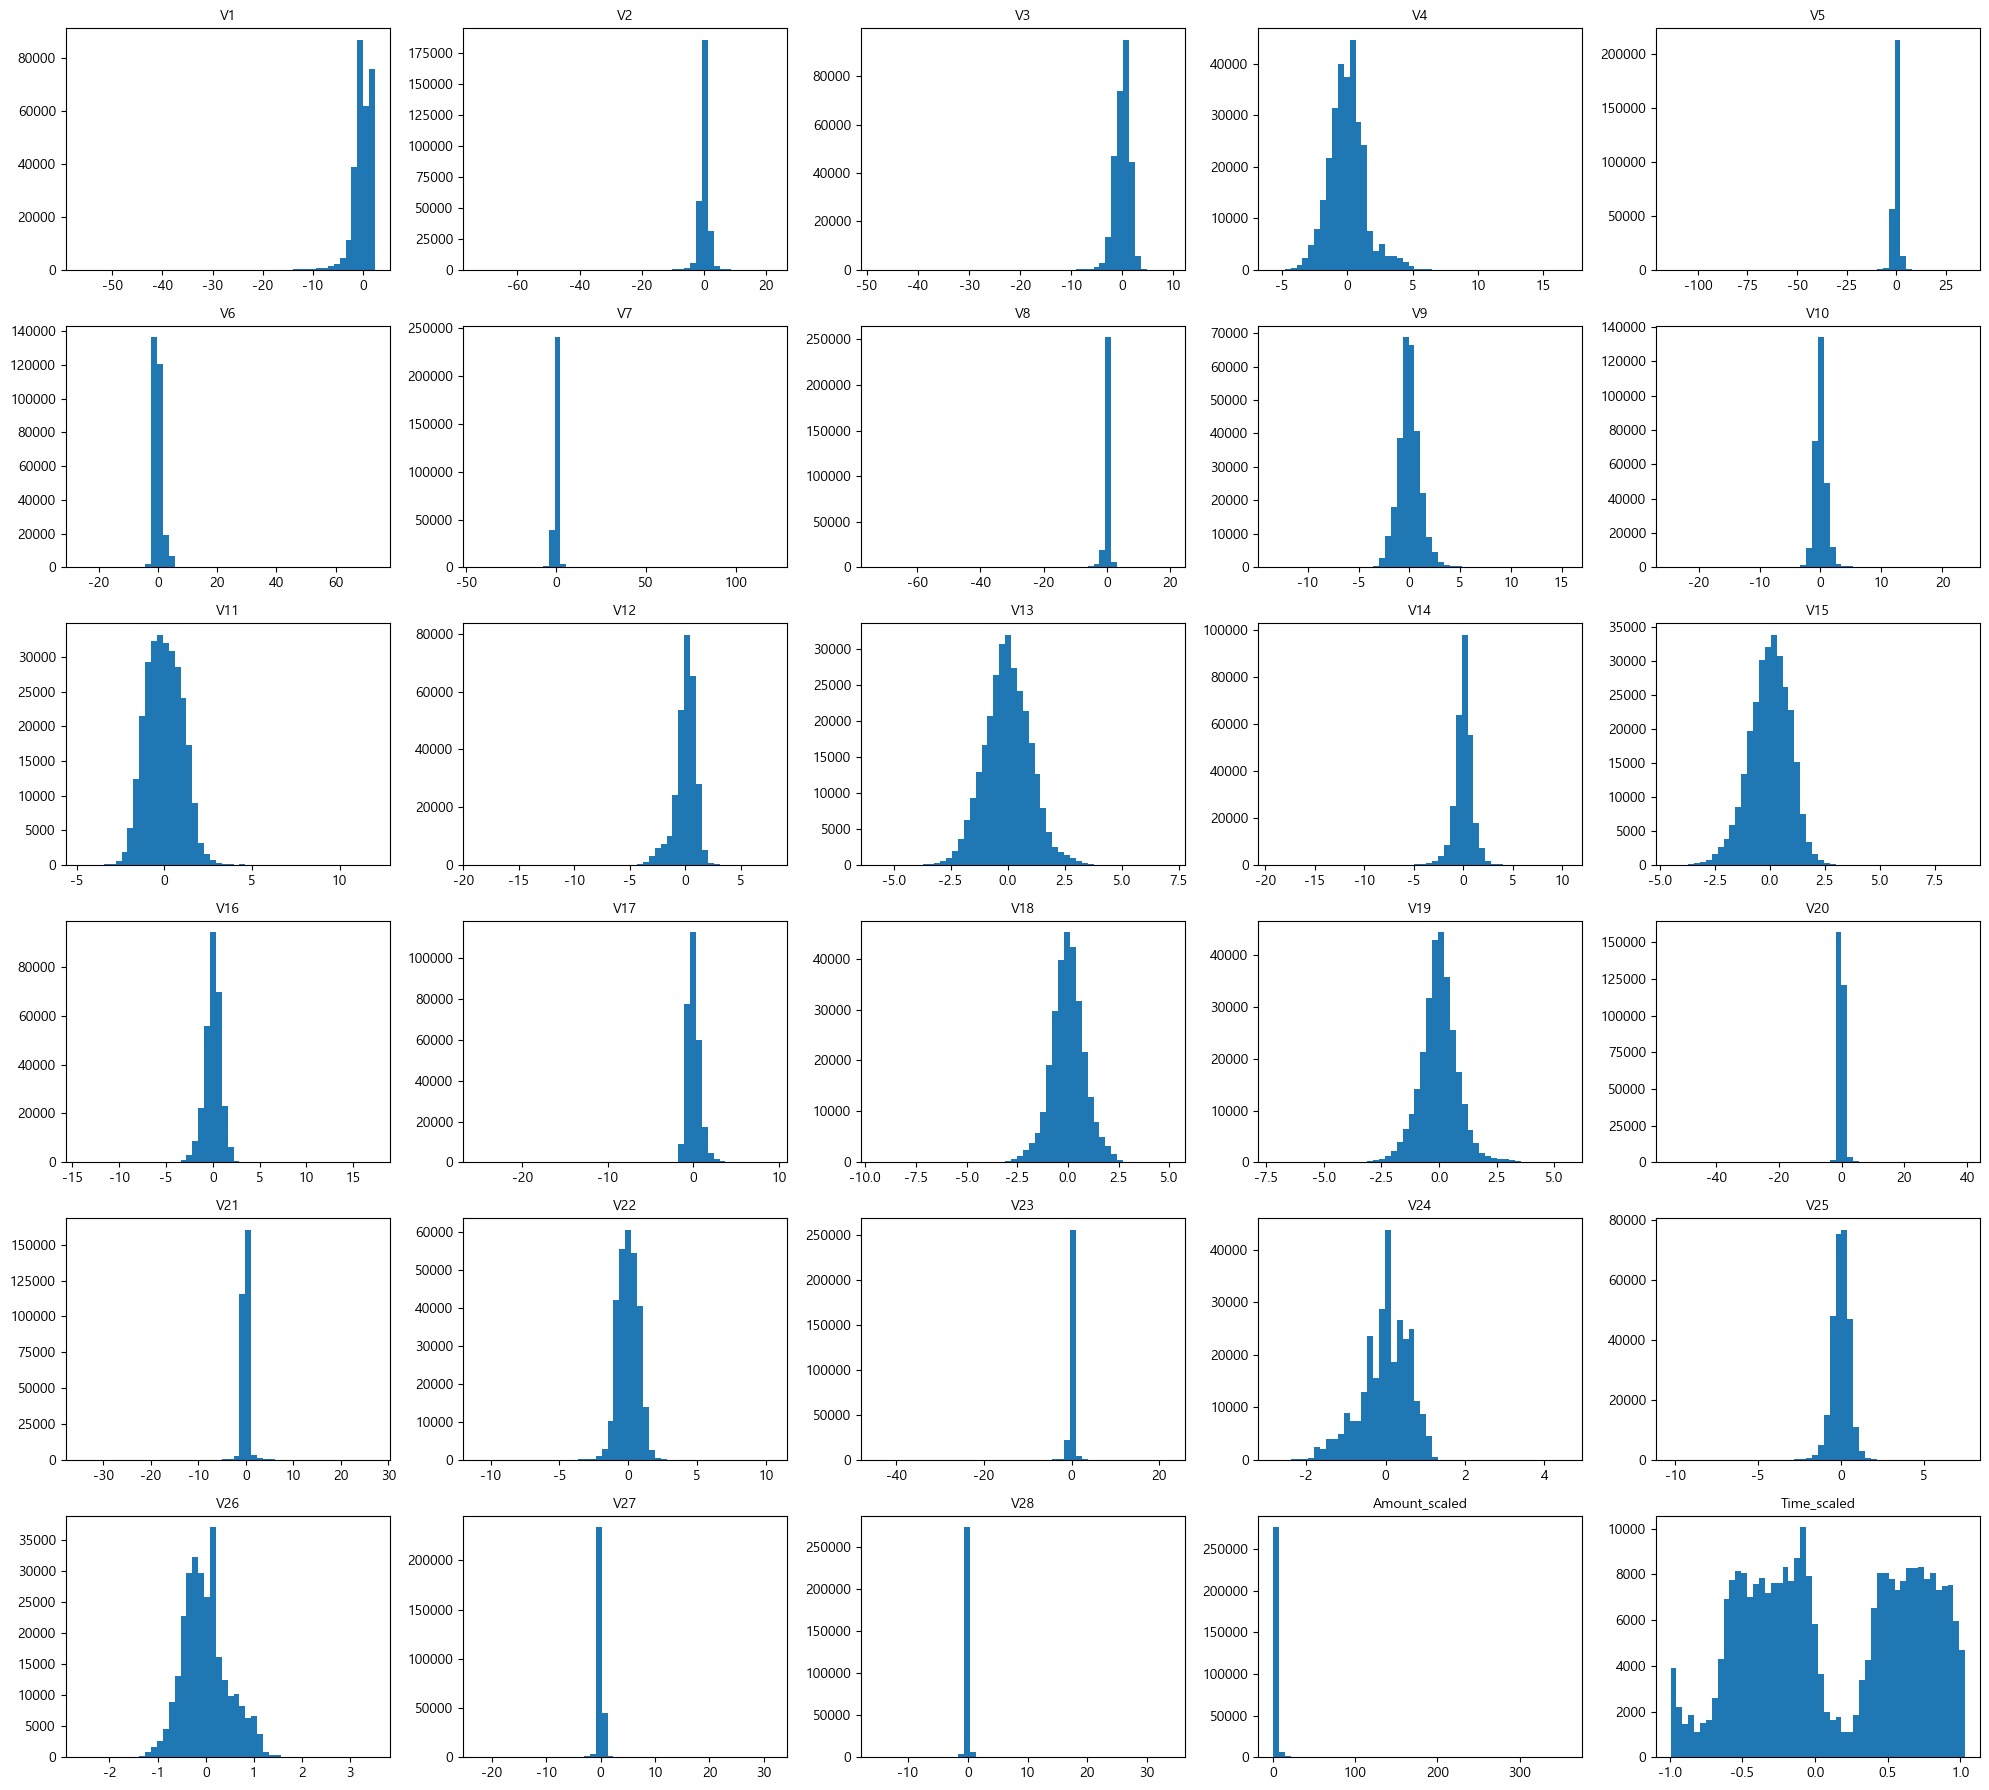

In [90]:
# Class 제외한 모든 피처
# 전체 피처 히스토그램 (원본 스케일 그대로, 이상치 포함)
feature_cols = [c for c in df_scaled.columns if c != 'Class']

n_cols = 5   # 한 줄에 5개씩
n_rows = (len(feature_cols) + n_cols - 1) // n_cols  # 필요한 행 수

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_scaled[col], bins=50)
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.show()

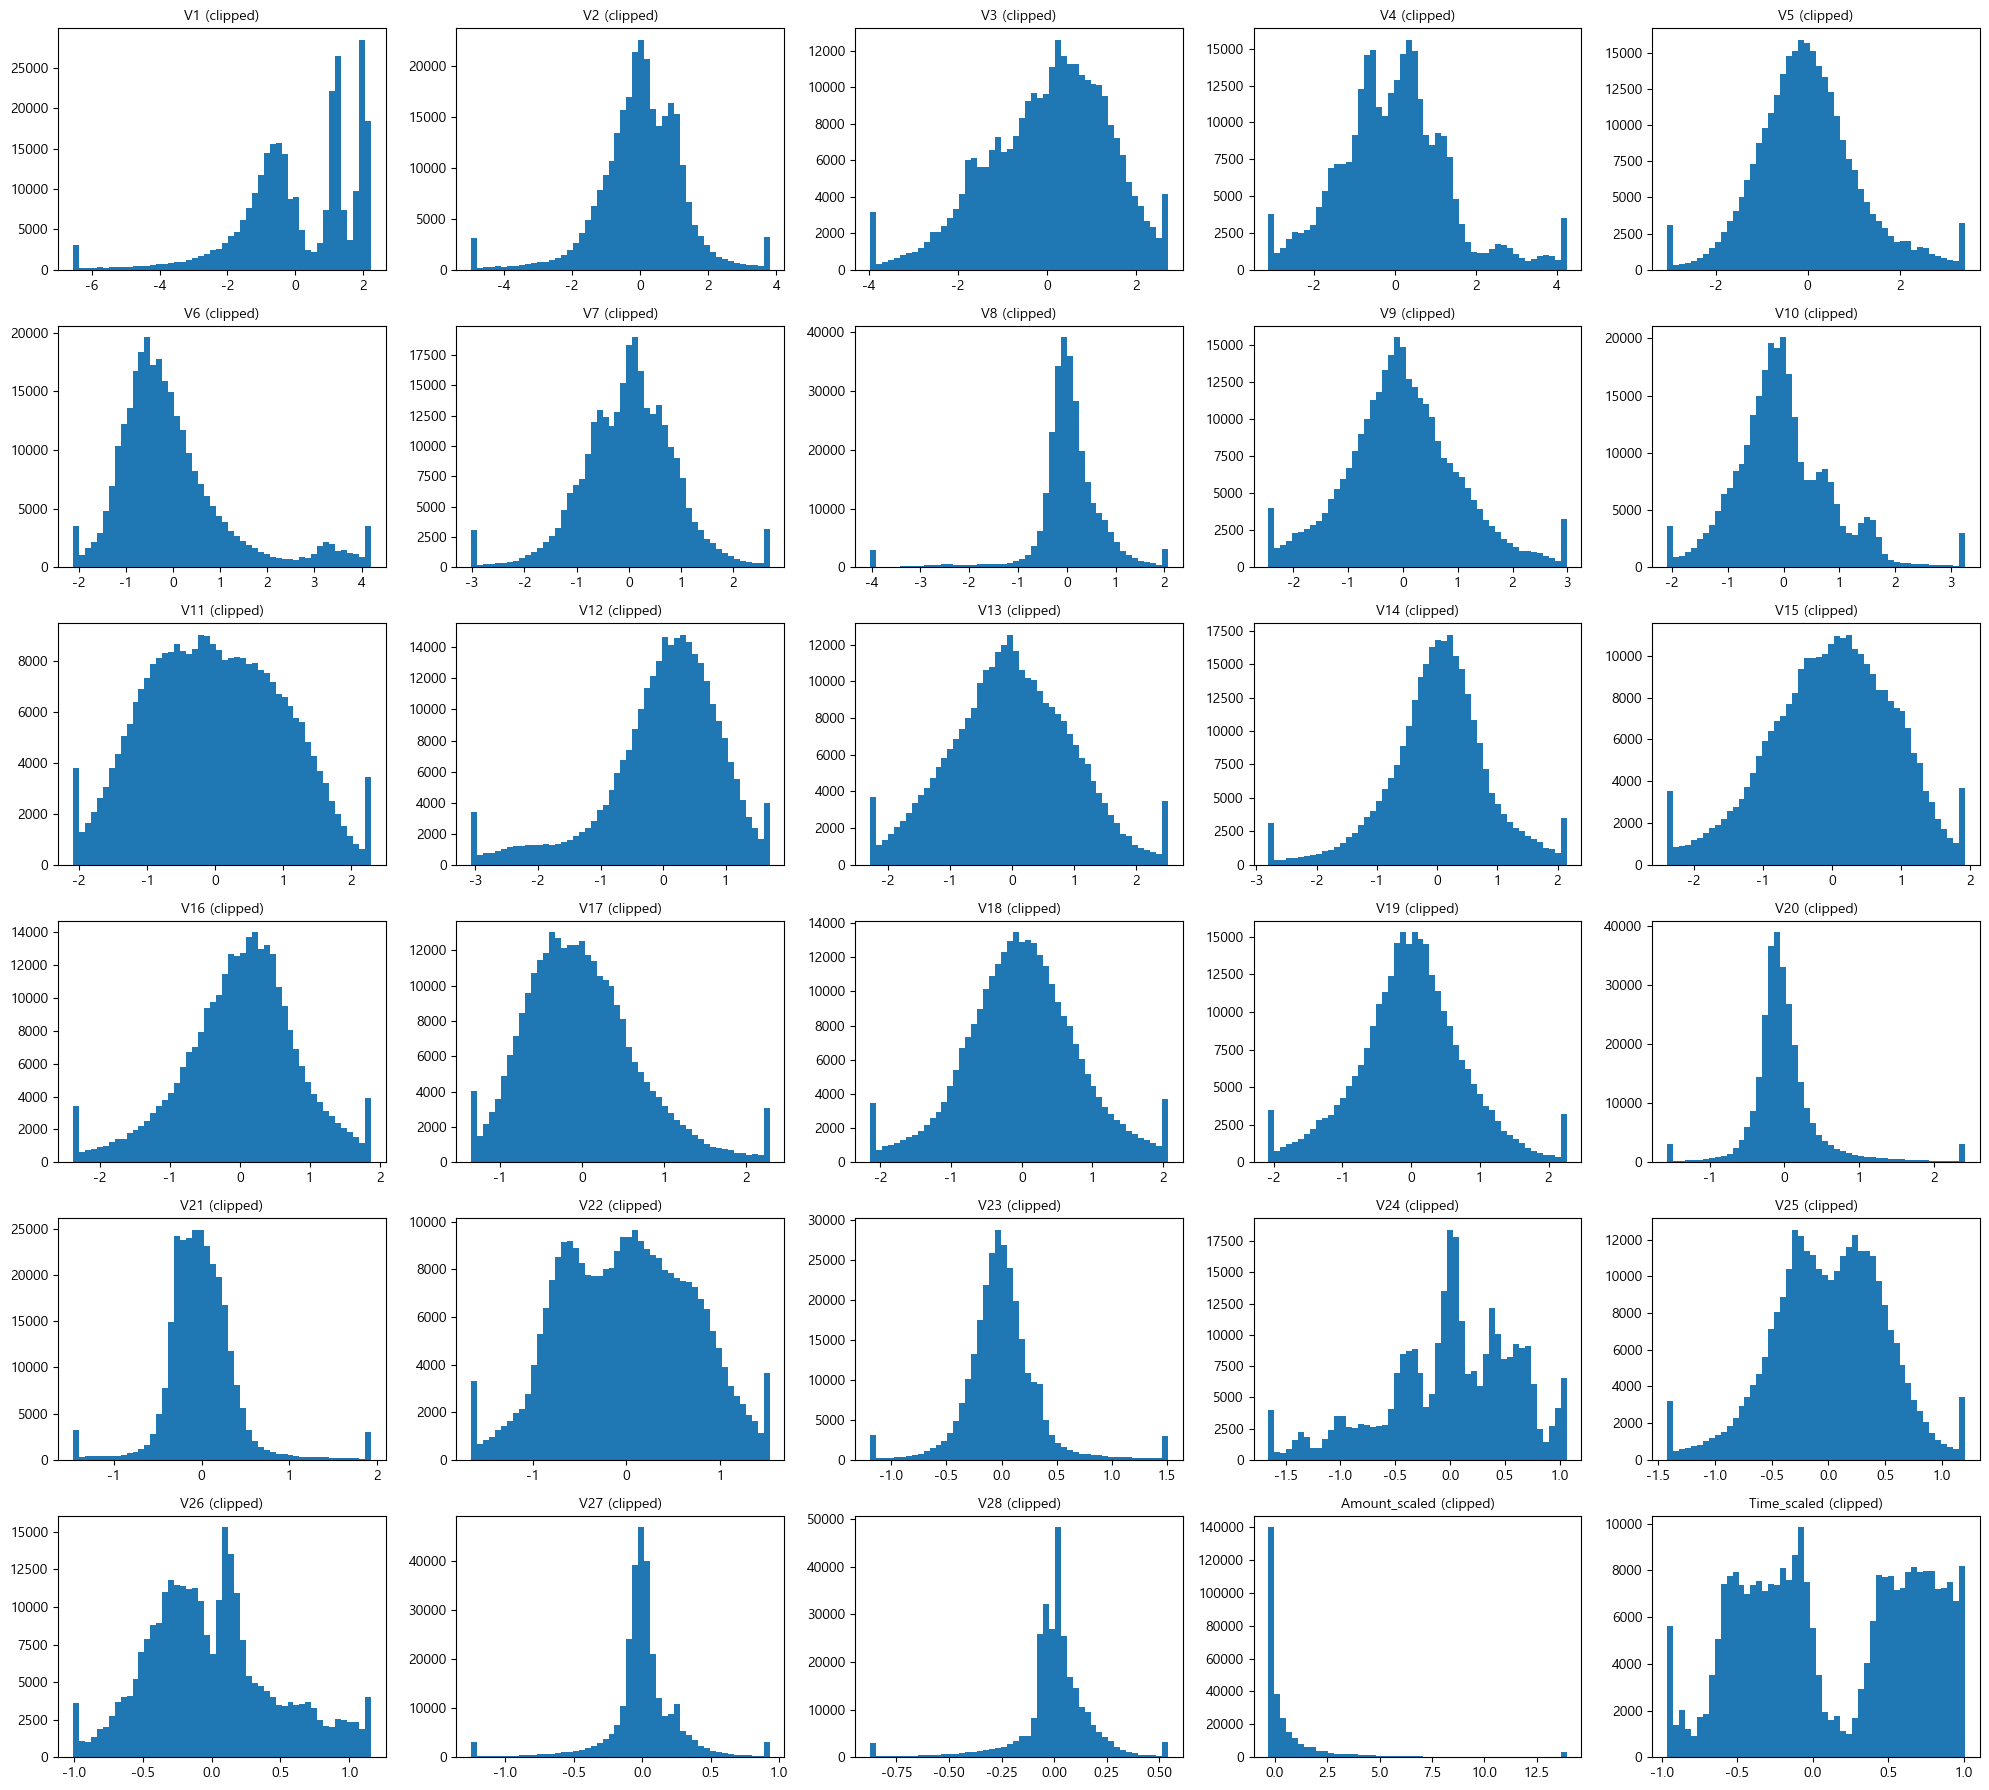

In [91]:
feature_cols = [c for c in df_scaled.columns if c != 'Class']

# 시각화용 복사본
df_clip = df_scaled.copy()

# 이상치 영향 줄인 히스토그램 (클리핑해서 보기)
# 각 피처별로 1%~99% 구간으로 클리핑
for col in feature_cols:
    q01 = df_clip[col].quantile(0.01)
    q99 = df_clip[col].quantile(0.99)
    df_clip[col] = df_clip[col].clip(lower=q01, upper=q99)

n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_clip[col], bins=50)
    plt.title(col + " (clipped)", fontsize=10)
    plt.tight_layout()

plt.show()

In [92]:
# 사기 거래만 필터링
df_fraud = df_scaled[df_scaled['Class'] == 1].copy()
print(df_fraud.shape)   # (사기 거래 개수, 31)

(492, 31)


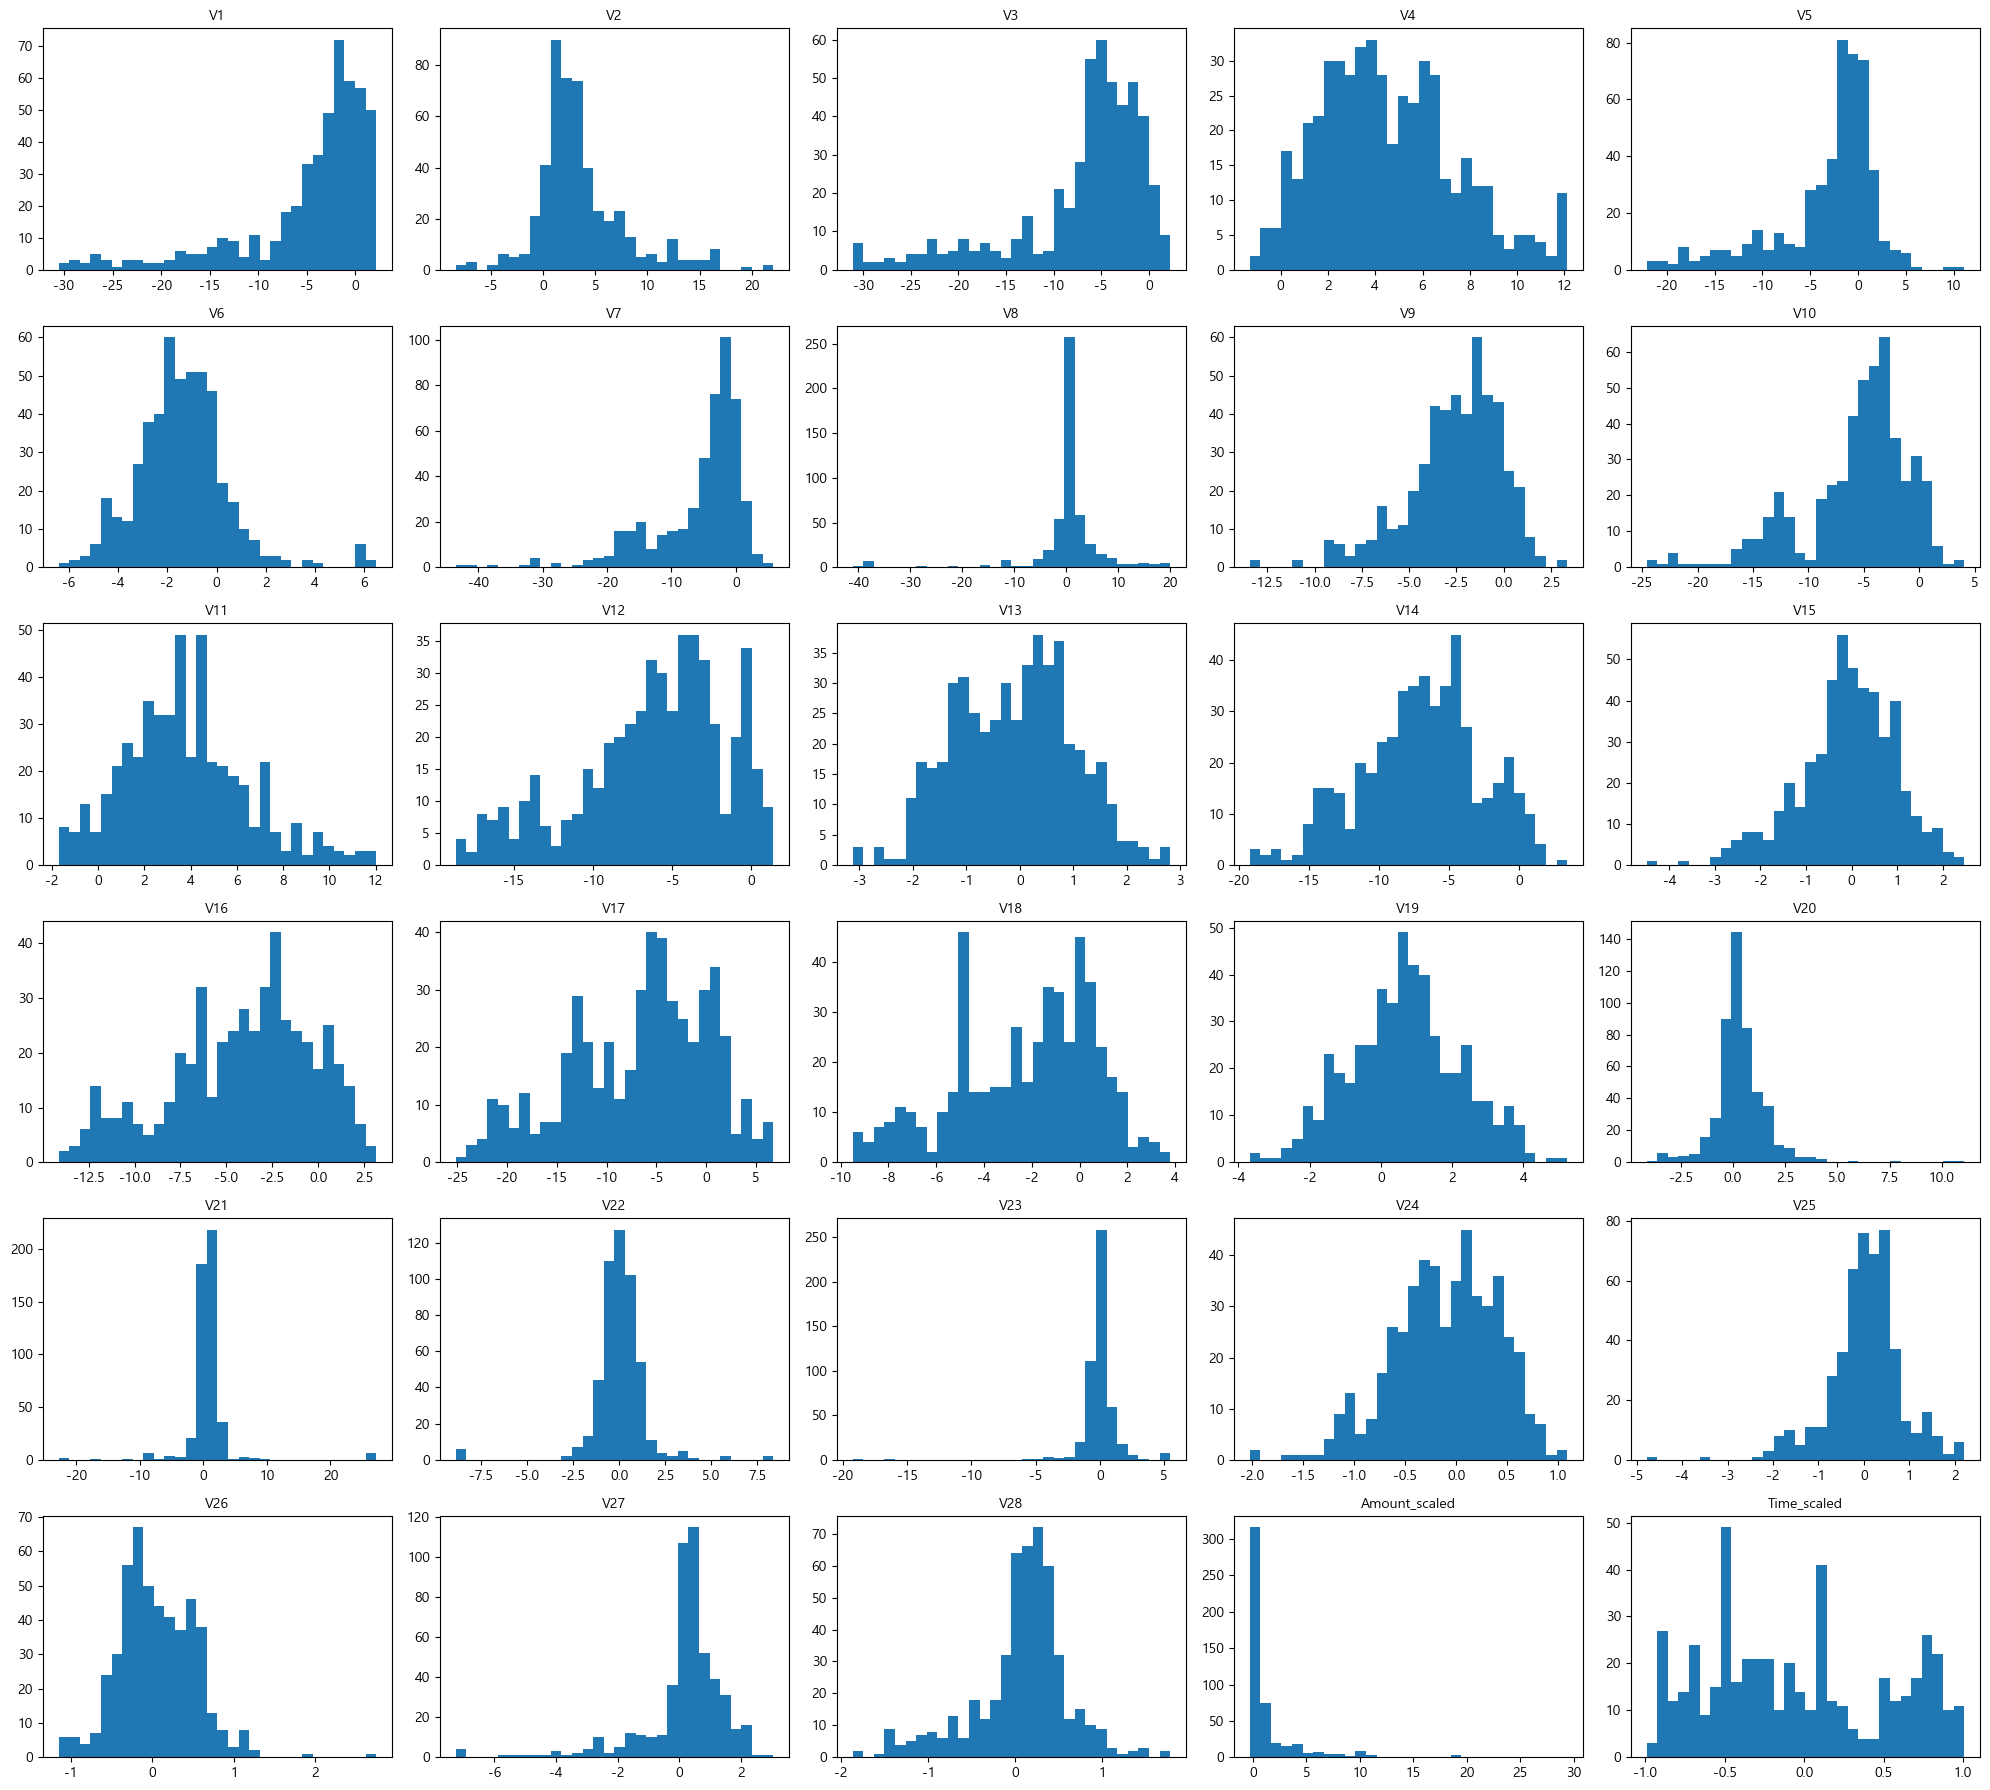

In [93]:
# Class = 1
# df_fraud = df_scaled[df_scaled['Class'] == 1].copy()
feature_cols = [c for c in df_fraud.columns if c != 'Class']

n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_fraud[col], bins=30)   # 사기 데이터가 적어서 bin 수는 조금 줄임
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.show()

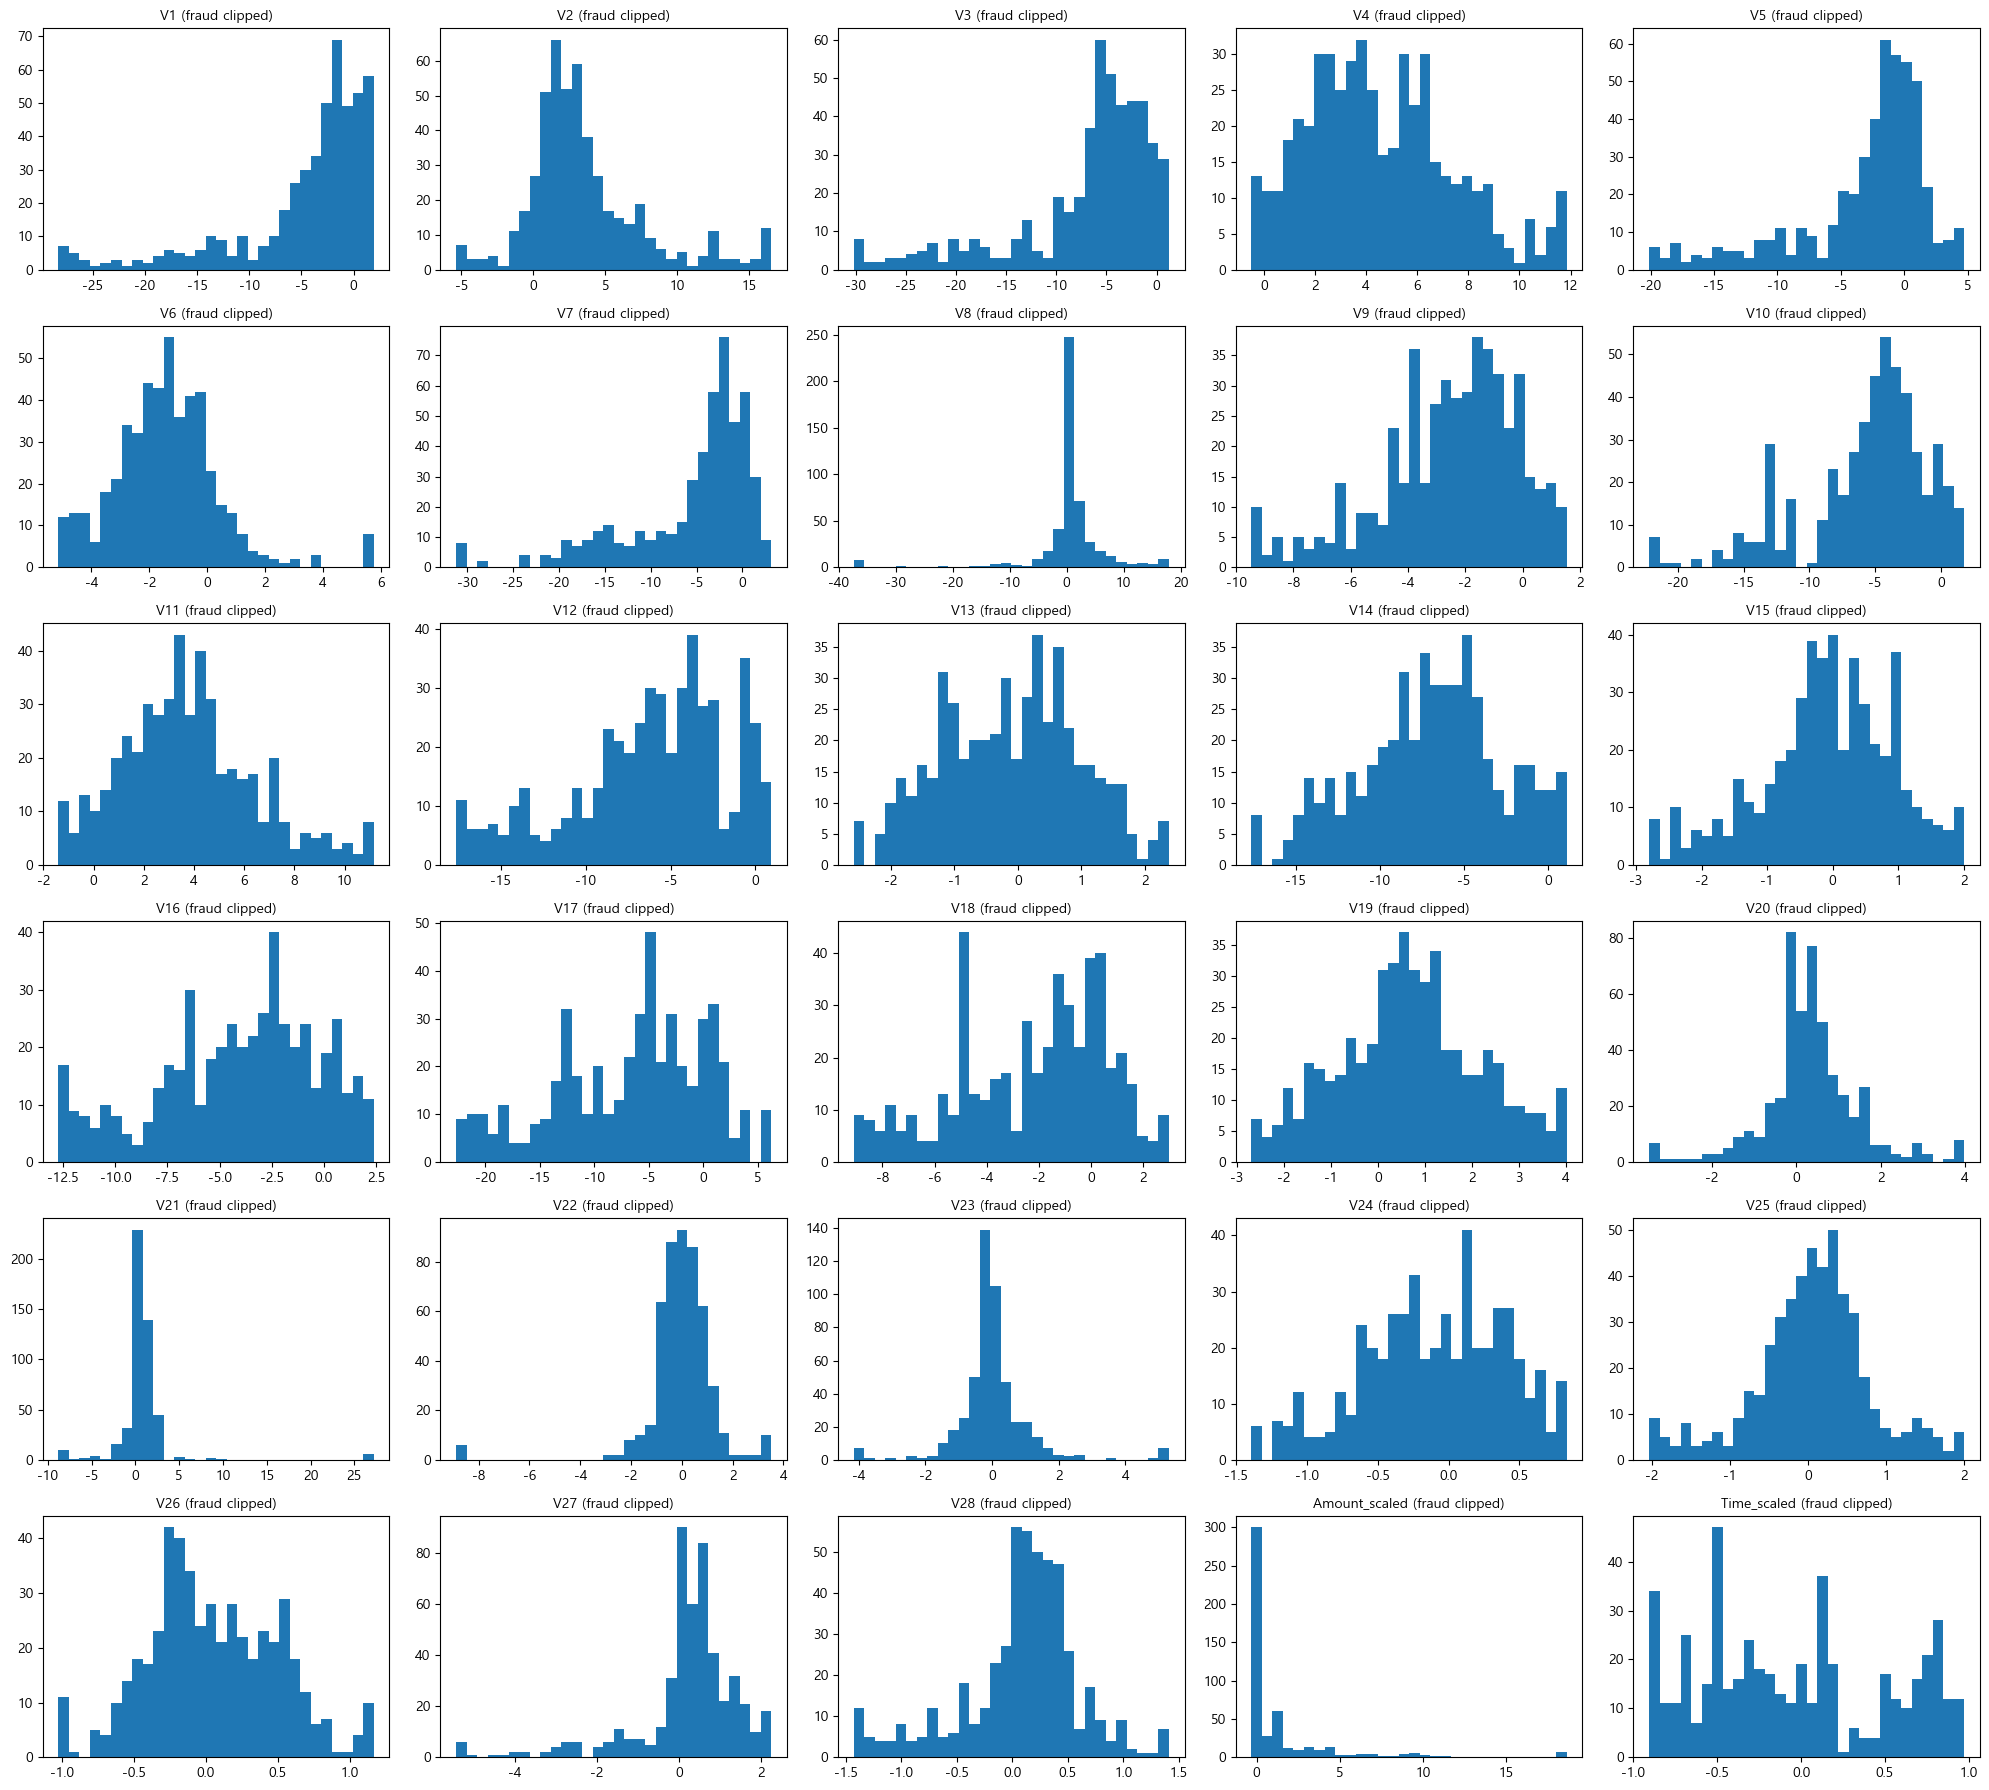

In [94]:
# Class = 1 대상으로 이상치 영향 줄인 히스토그램 (클리핑)
# 각 피처별로 1%~99% 구간으로 클리핑
df_fraud_clip = df_fraud.copy()
feature_cols = [c for c in df_fraud_clip.columns if c != 'Class']

# 각 피처별 1%~99% 구간으로 클리핑 (시각화용)
for col in feature_cols:
    q01 = df_fraud_clip[col].quantile(0.01)
    q99 = df_fraud_clip[col].quantile(0.99)
    df_fraud_clip[col] = df_fraud_clip[col].clip(lower=q01, upper=q99)

n_cols = 5
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_fraud_clip[col], bins=30)
    plt.title(col + " (fraud clipped)", fontsize=10)
    plt.tight_layout()

plt.show()

In [95]:
def plot_box_grid_all(df, feature_cols, title, n_cols=5):
    """Class 0,1 모두 있는 데이터용 (x축 Class, y축 feature)"""
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(data=df, x='Class', y=col, ax=axes[i])
        axes[i].set_title(col, fontsize=9)

    # 안 쓰는 subplot 지우기
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_box_grid_fraud(df, feature_cols, title, n_cols=5):
    """Class=1만 있는 데이터용 (y축만 feature)"""
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

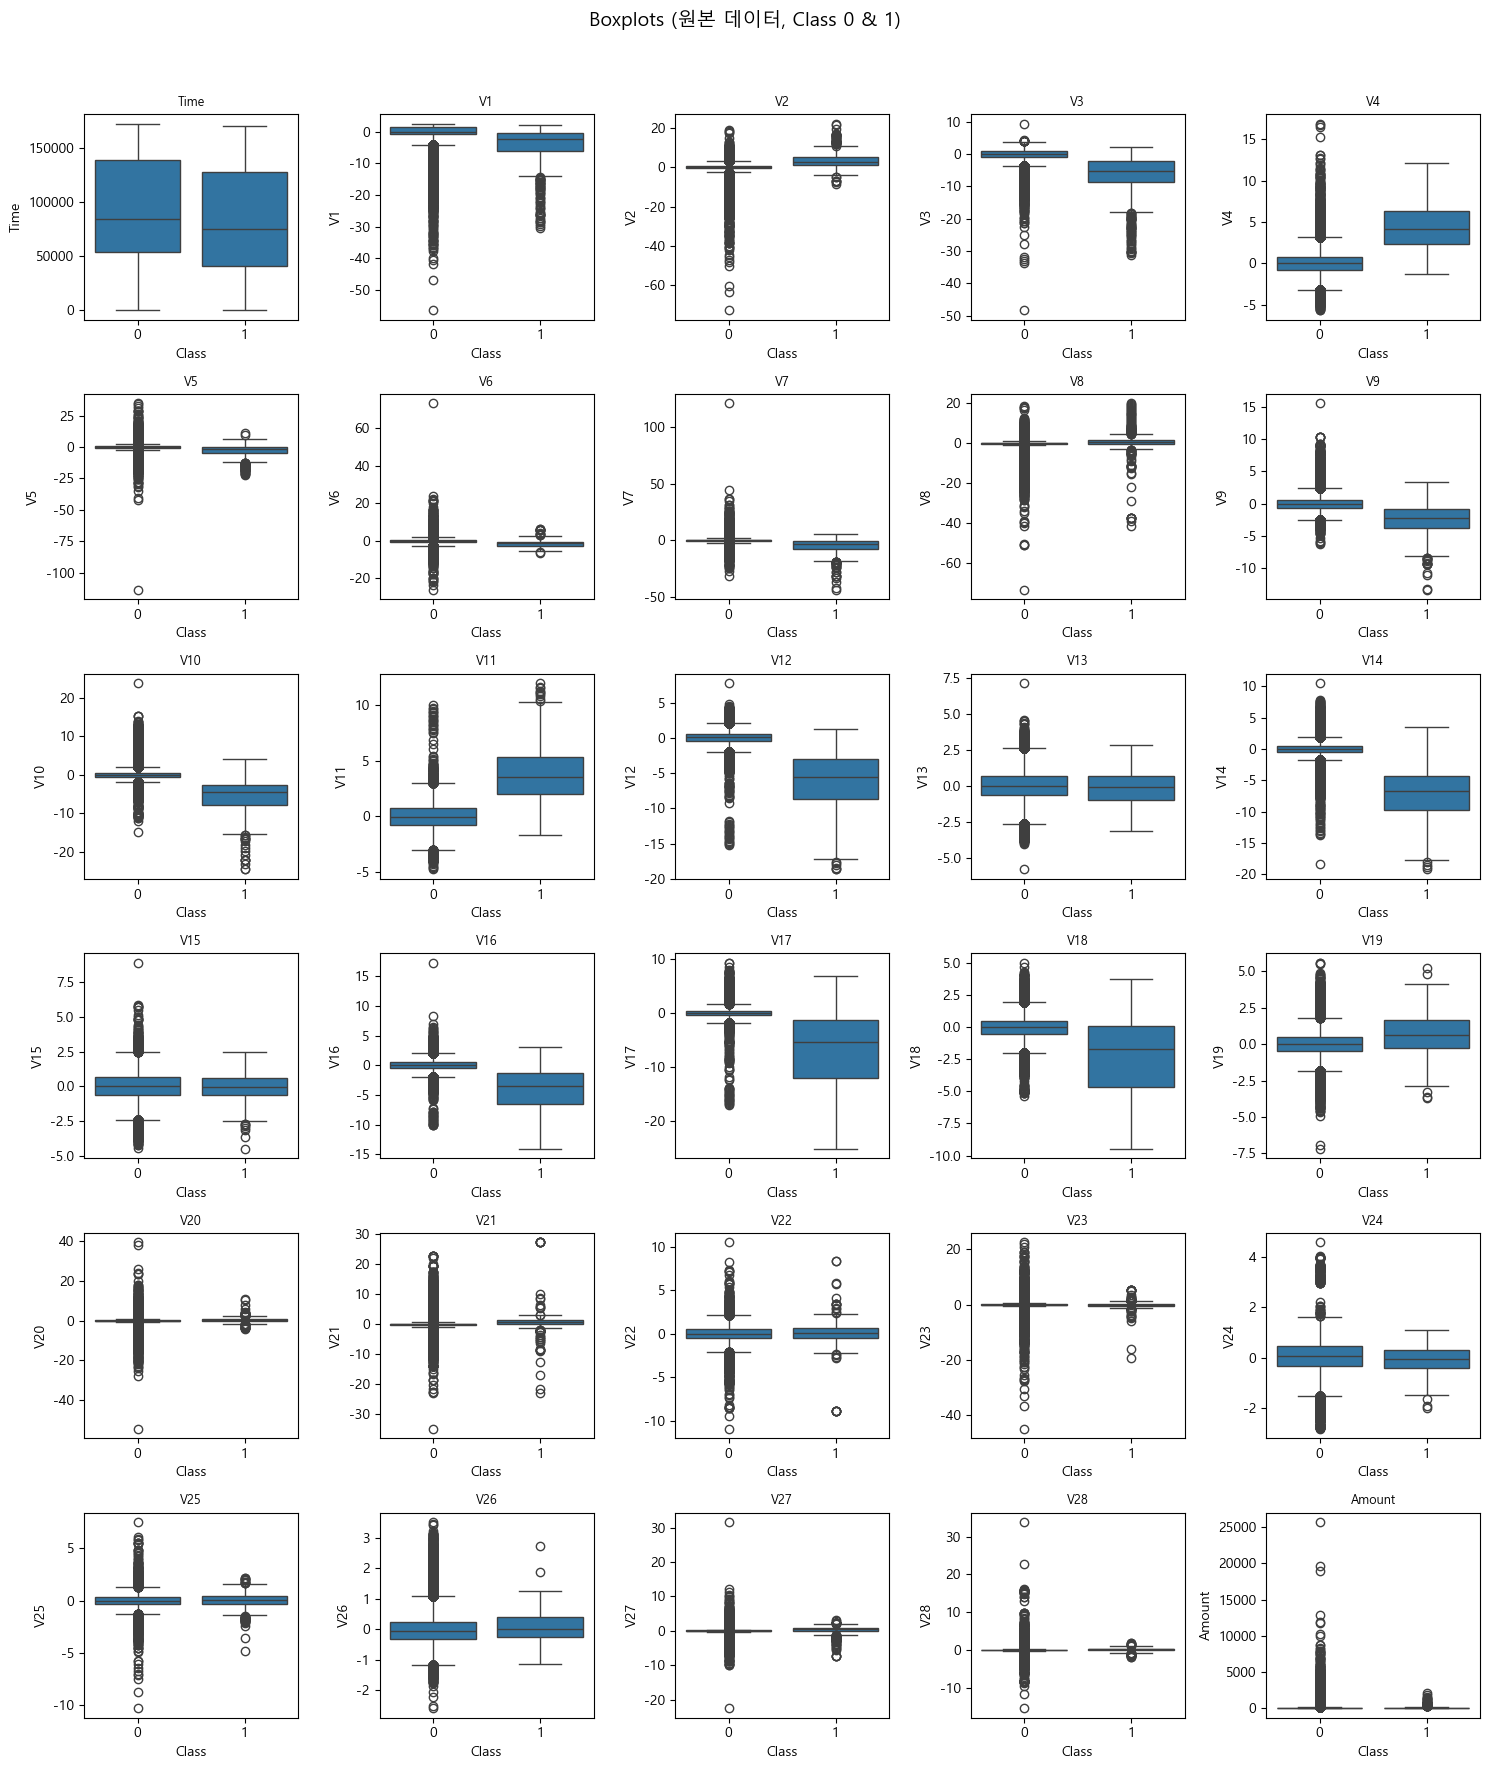

In [96]:
# 1) class=0,1 전부 (원본)
# 원본 df 기준 피처 목록 (Class만 제외)
feature_cols_all_raw = [c for c in df.columns if c != 'Class']

plot_box_grid_all(
    df=df,
    feature_cols=feature_cols_all_raw,
    title='Boxplots (원본 데이터, Class 0 & 1)'
)

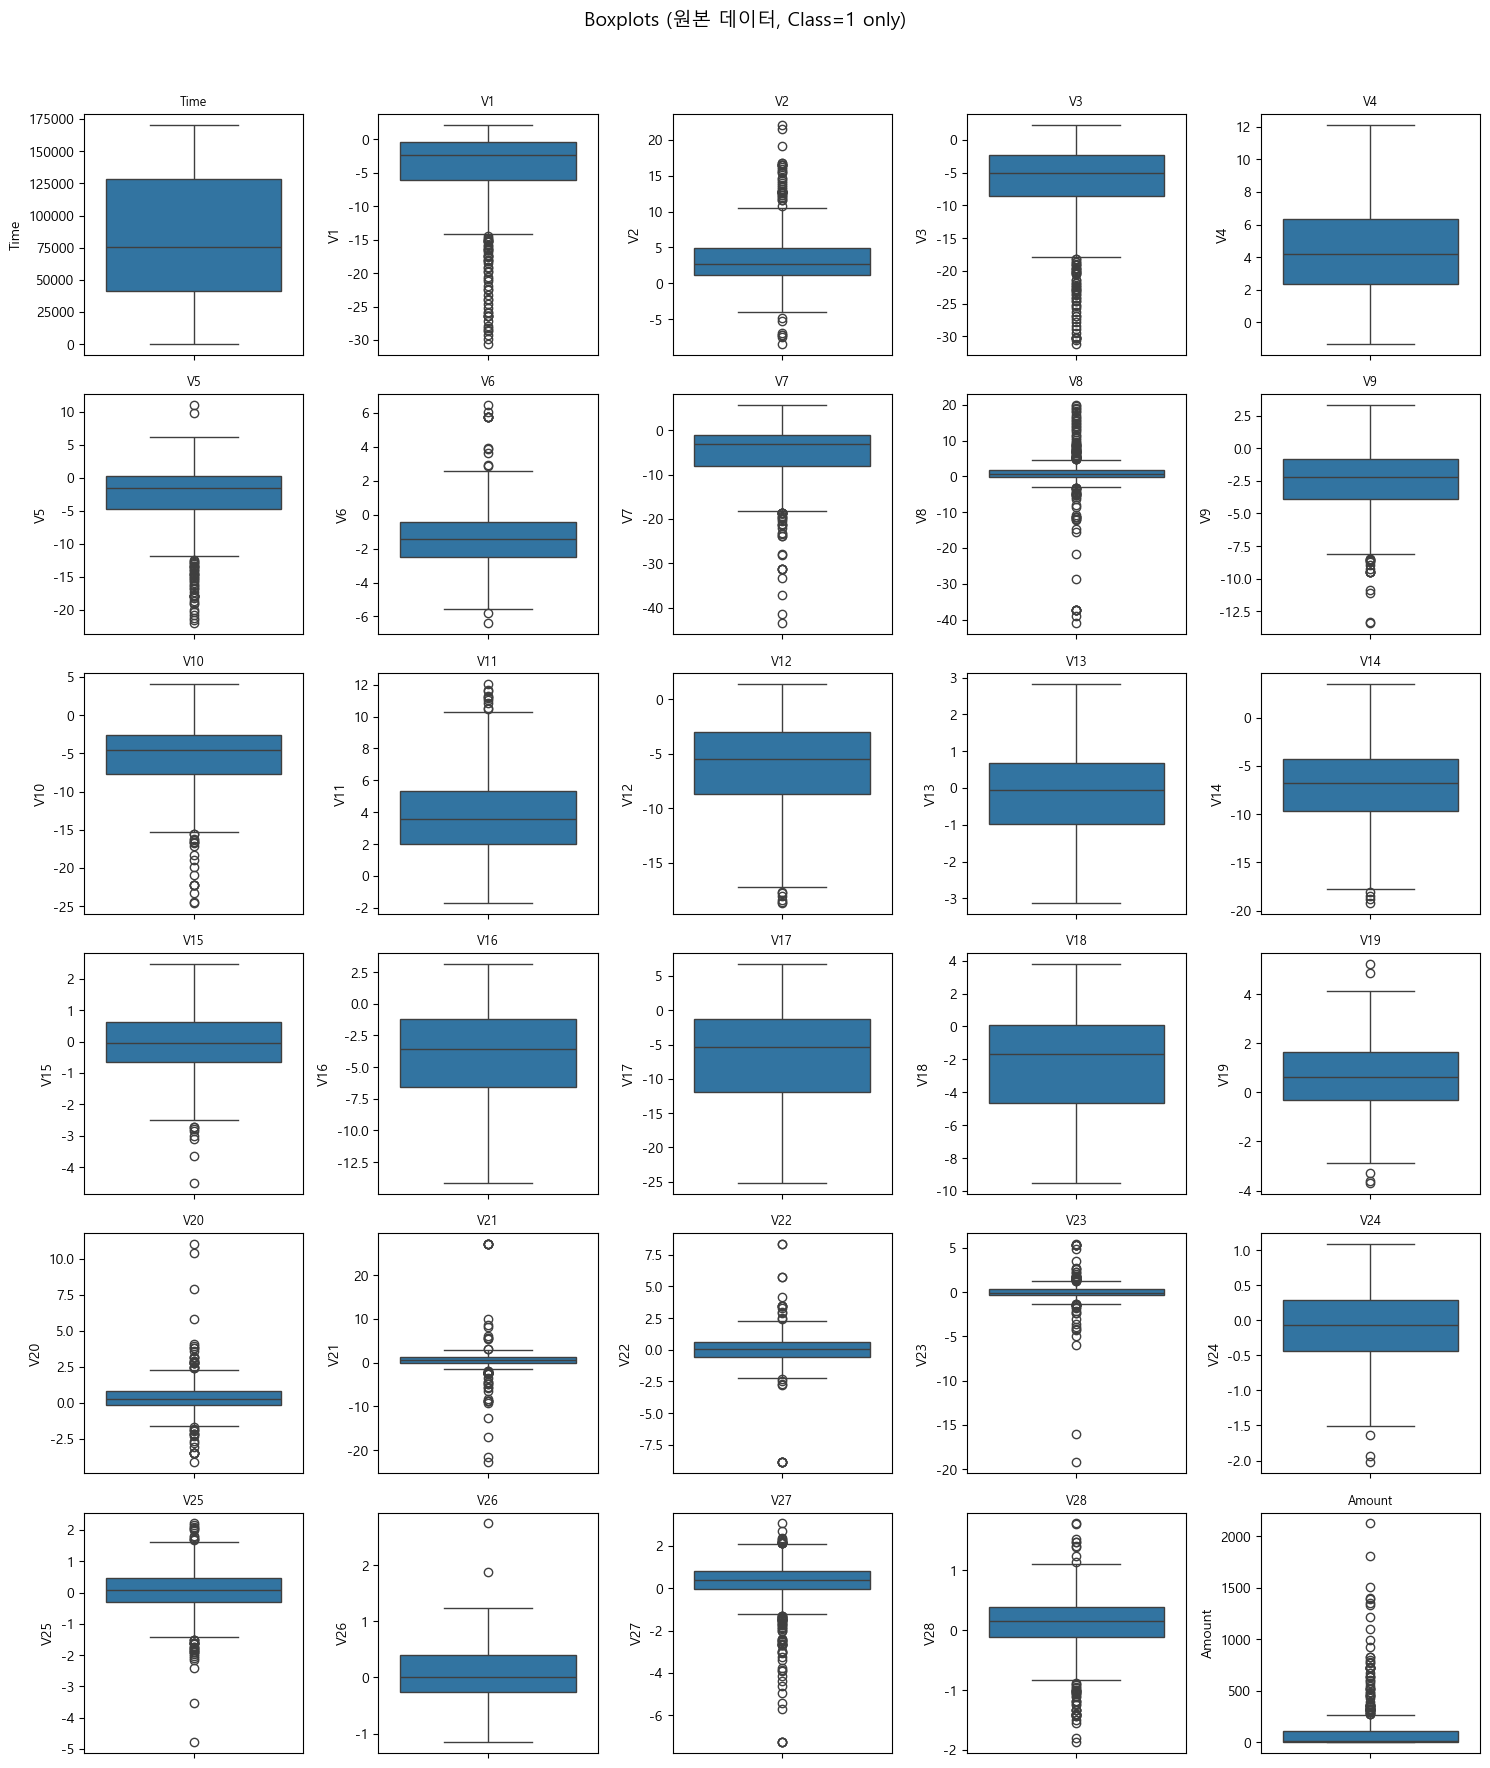

In [97]:
# 2) class=1만 (원본)
df_fraud_raw = df[df['Class'] == 1].copy()

plot_box_grid_fraud(
    df=df_fraud_raw,
    feature_cols=feature_cols_all_raw,  # Class 빼고 모두
    title='Boxplots (원본 데이터, Class=1 only)'
)

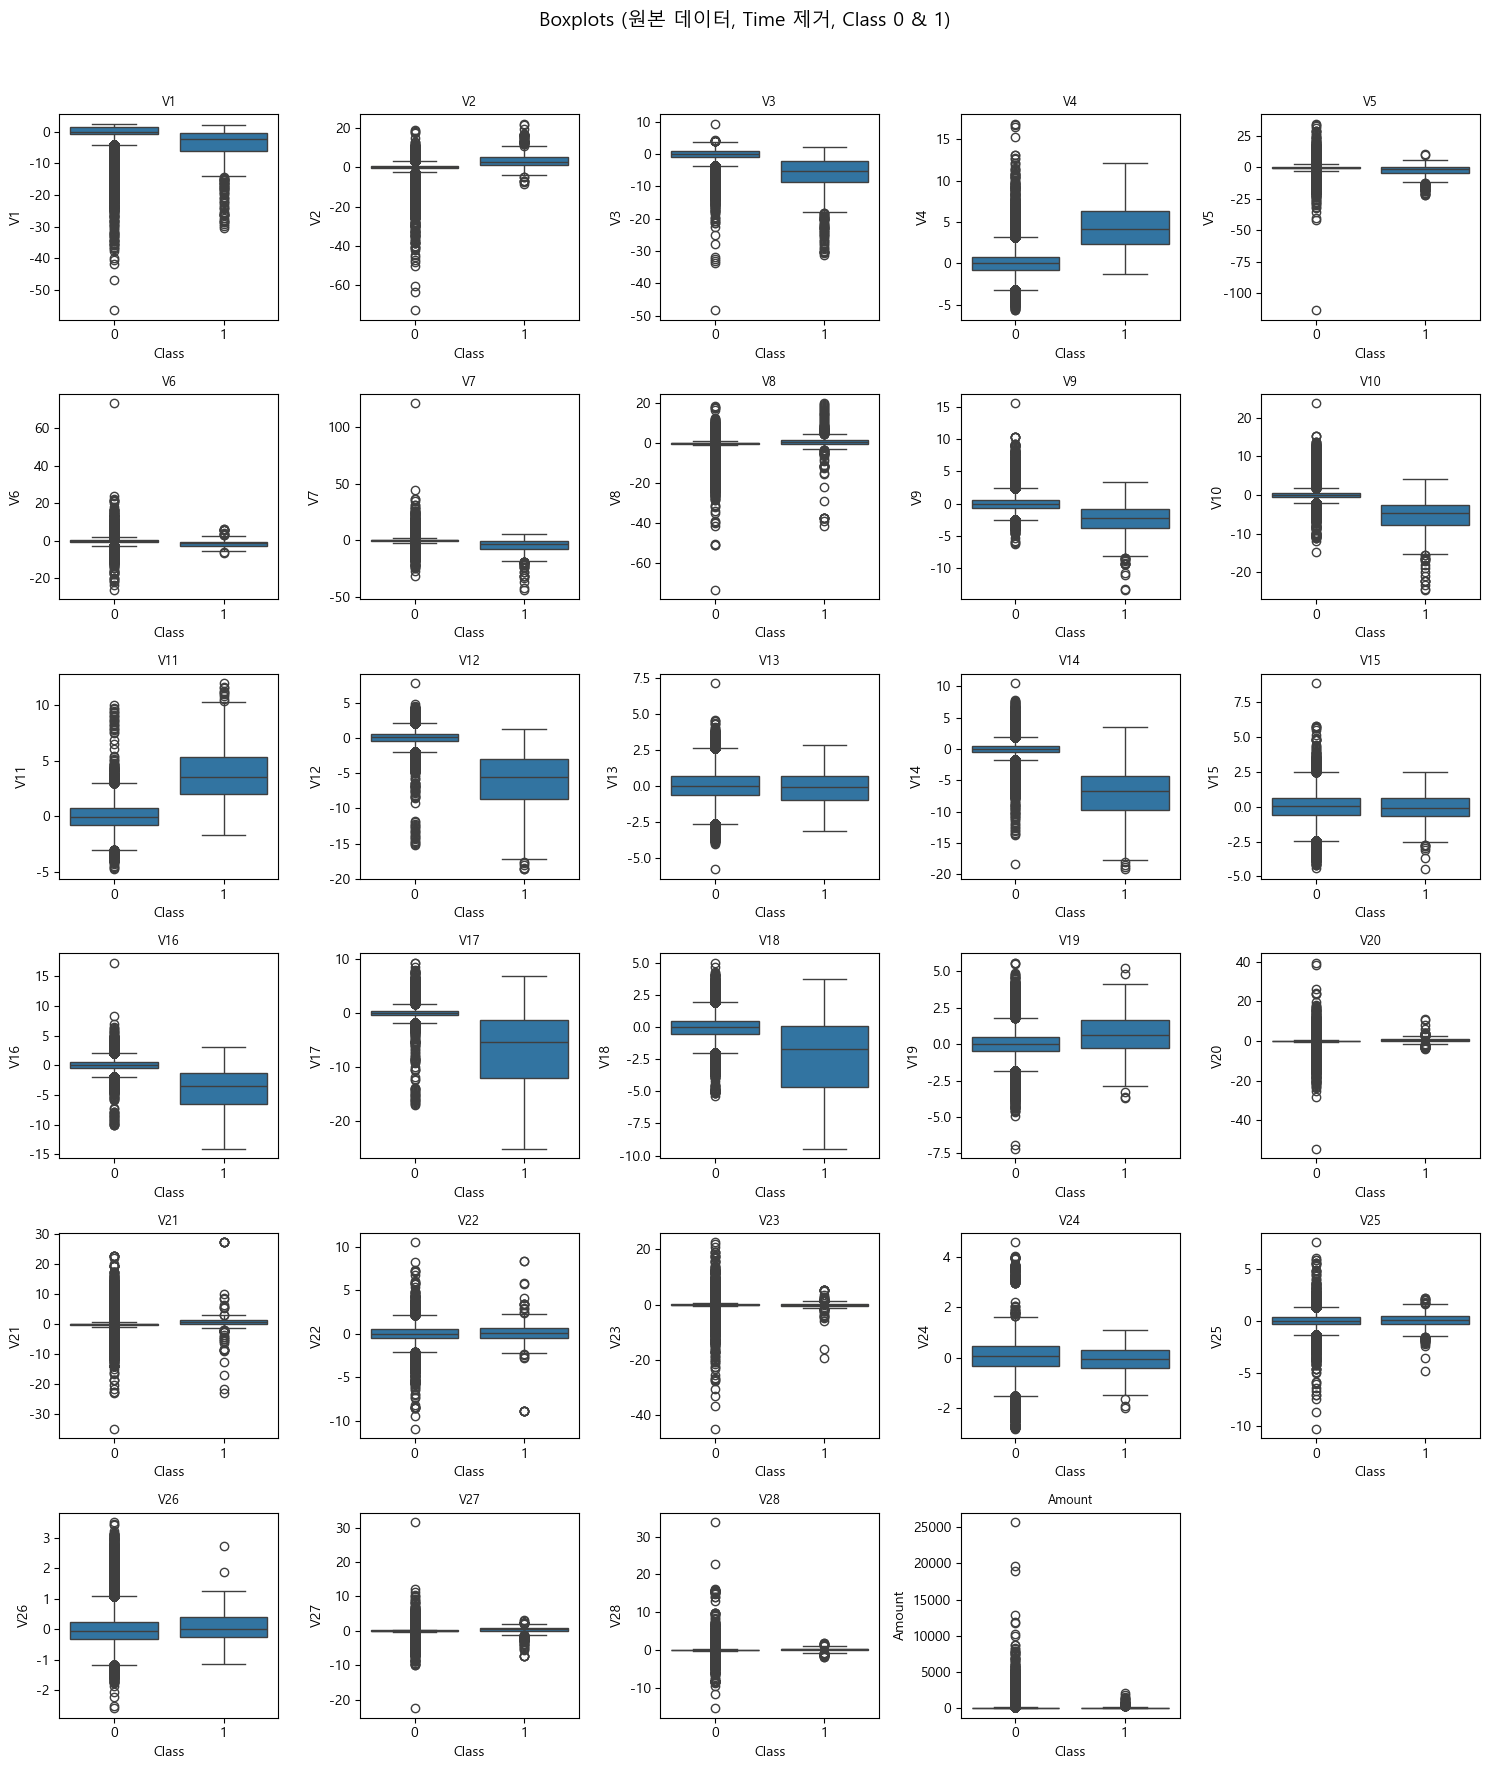

In [98]:
# 3) time이 제거된 버전 (원본 기준)

feature_cols_no_time_raw = [
    c for c in df.columns
    if c not in ['Class', 'Time']
]

plot_box_grid_all(
    df=df,
    feature_cols=feature_cols_no_time_raw,
    title='Boxplots (원본 데이터, Time 제거, Class 0 & 1)'
)

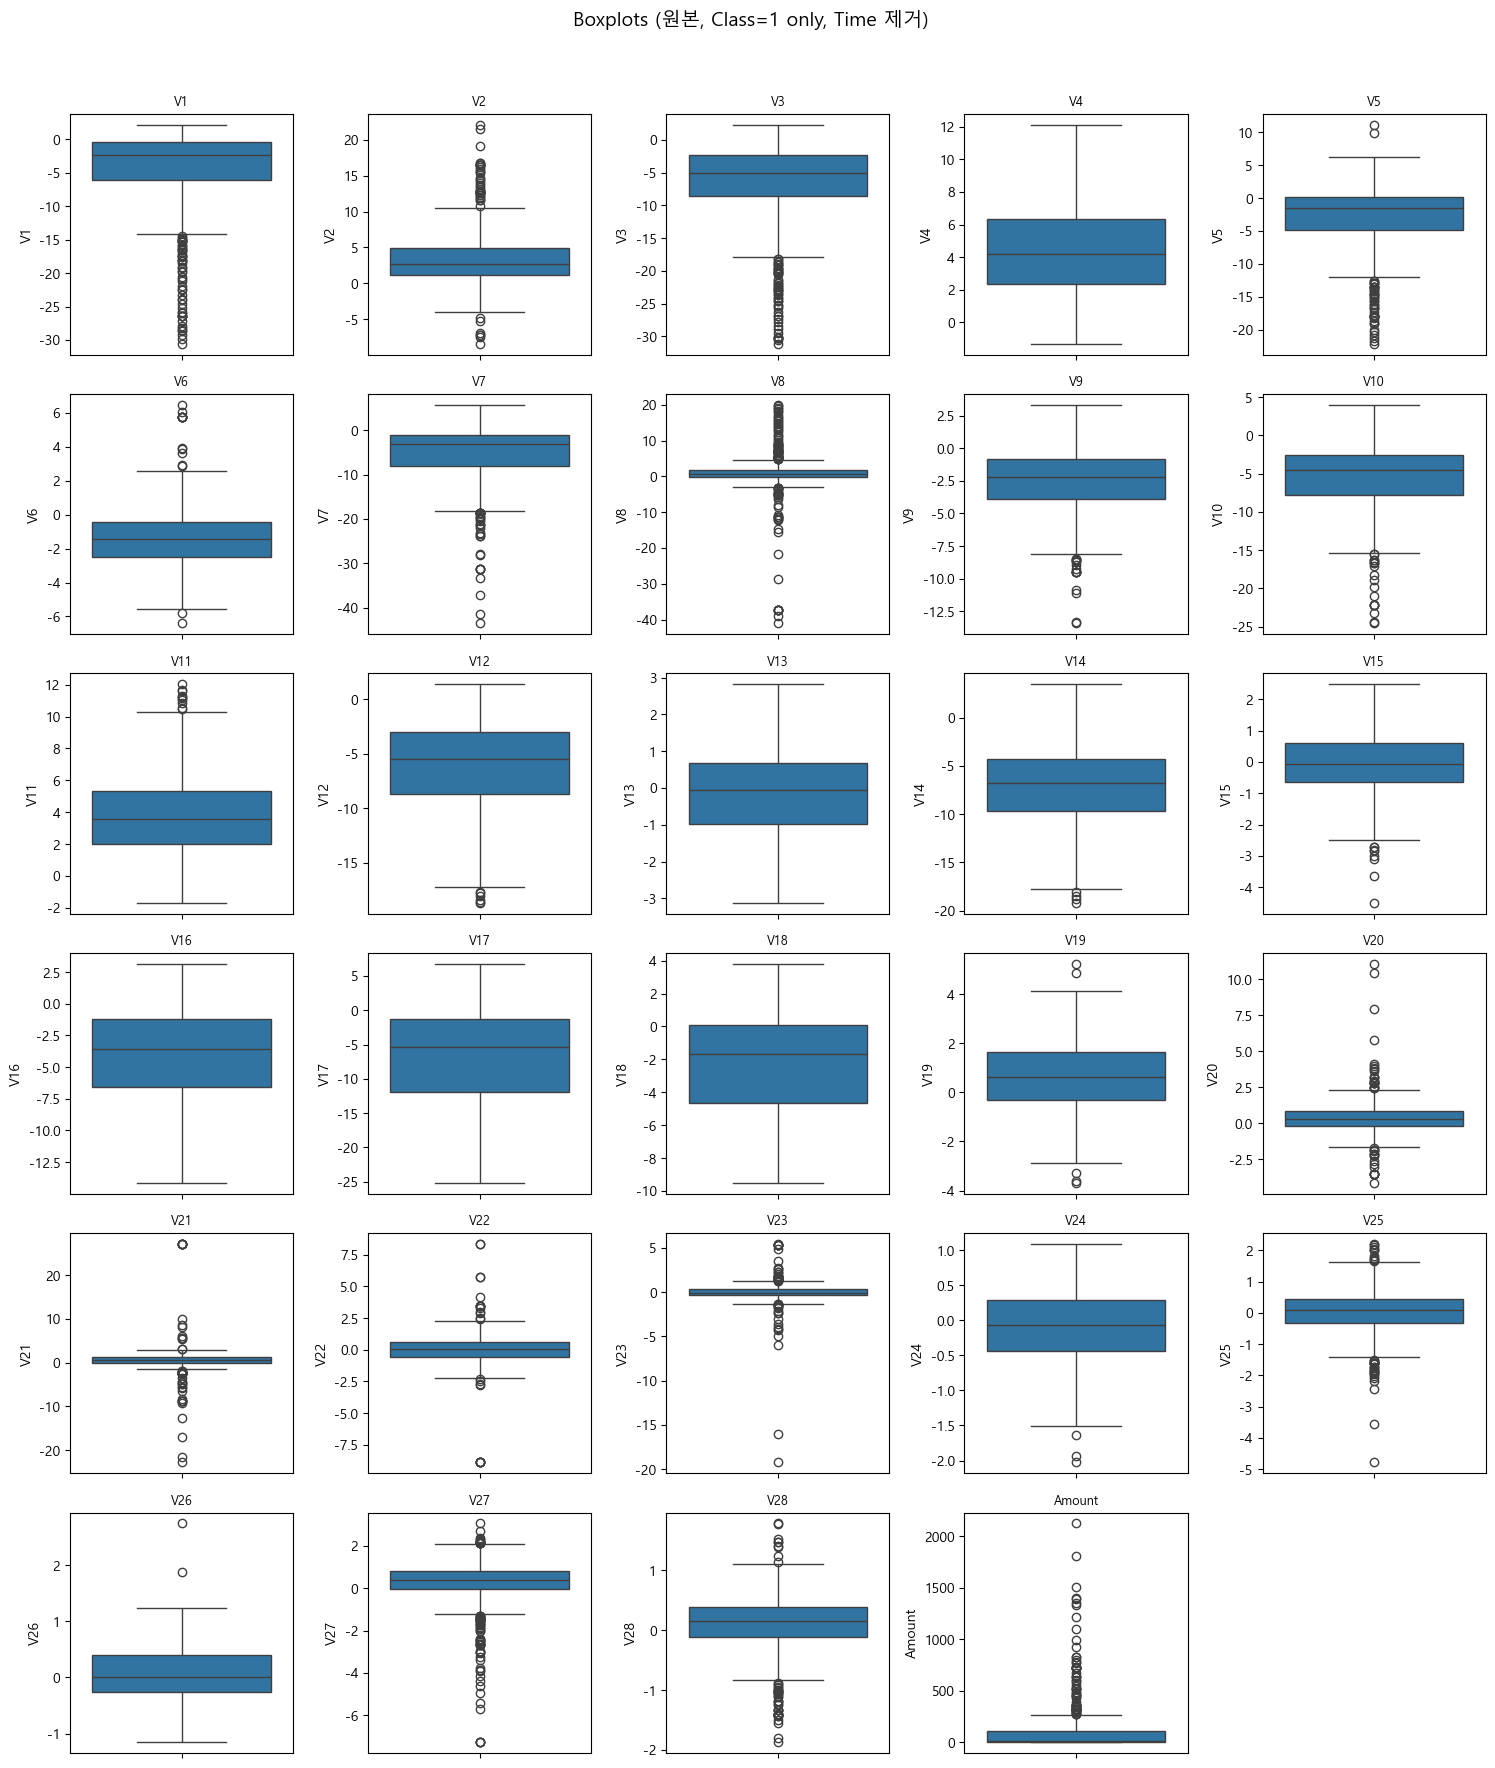

In [99]:
# Class=1만 + Time 제거한 피처 목록
df_fraud_raw = df[df['Class'] == 1].copy()

feature_cols_no_time_raw = [
    c for c in df.columns
    if c not in ['Class', 'Time']   # Class, Time 제거
]

def plot_box_grid_fraud(df_in, feature_cols, title, n_cols=5):
    """Class=1처럼 y축만 feature인 박스플롯을 그리기 위한 그리드 함수"""
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(y=df_in[col], ax=axes[i])
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    # 남는 subplot 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Class=1 & Time 제거 박스플롯
plot_box_grid_fraud(
    df_in=df_fraud_raw,
    feature_cols=feature_cols_no_time_raw,
    title='Boxplots (원본, Class=1 only, Time 제거)'
)

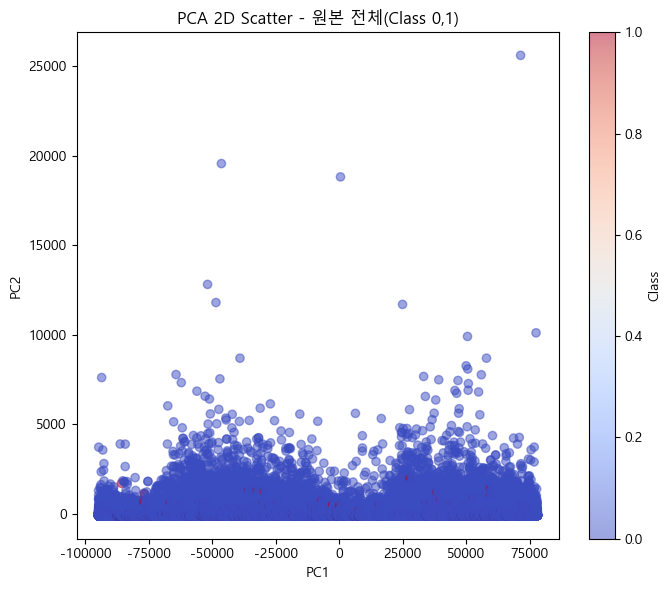

In [ ]:
# 1) 전체 (원본)
X_all_raw = df[feature_cols_all_raw]   # Class 제외 모두
y_all_raw = df['Class']

pca_all_raw = PCA(n_components=2, random_state=42)
X_all_raw_2d = pca_all_raw.fit_transform(X_all_raw)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_all_raw_2d[:, 0], X_all_raw_2d[:, 1],
                      c=y_all_raw, cmap='coolwarm', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본 전체(Class 0,1)')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.show()

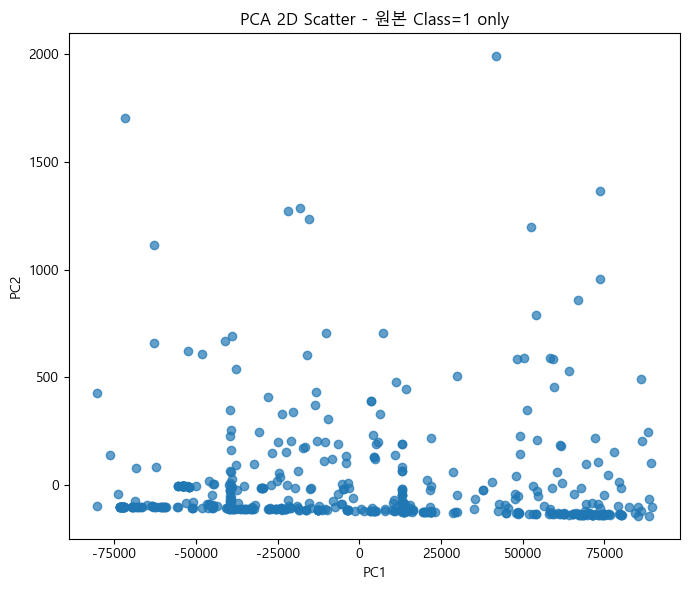

In [101]:
# 2) class=1만 (원본)
X_fraud_raw = df_fraud_raw[feature_cols_all_raw]

pca_fraud_raw = PCA(n_components=2, random_state=42)
X_fraud_raw_2d = pca_fraud_raw.fit_transform(X_fraud_raw)

plt.figure(figsize=(7, 6))
plt.scatter(X_fraud_raw_2d[:, 0], X_fraud_raw_2d[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본 Class=1 only')
plt.tight_layout()
plt.show()

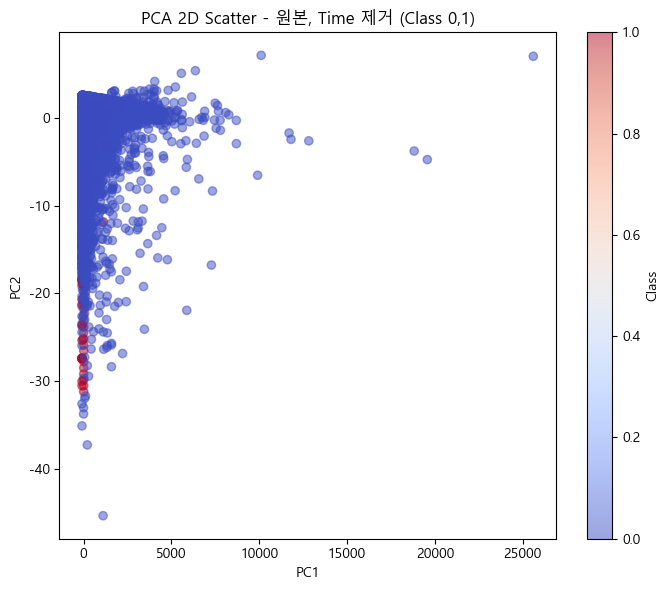

In [102]:
# 3) time 제거 버전 (원본 Time 제거)
X_no_time_raw = df[feature_cols_no_time_raw]
y_no_time_raw = df['Class']

pca_no_time_raw = PCA(n_components=2, random_state=42)
X_no_time_raw_2d = pca_no_time_raw.fit_transform(X_no_time_raw)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_no_time_raw_2d[:, 0], X_no_time_raw_2d[:, 1],
                      c=y_no_time_raw, cmap='coolwarm', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본, Time 제거 (Class 0,1)')
plt.colorbar(scatter, label='Class')
plt.tight_layout()
plt.show()

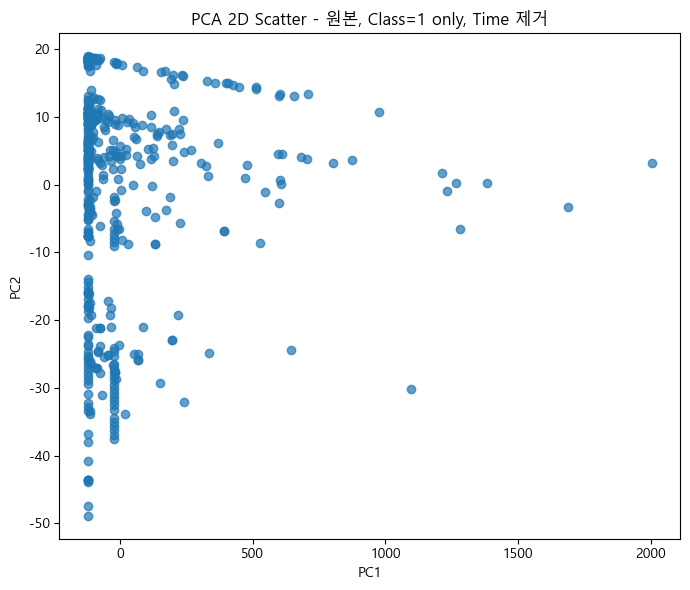

In [103]:
# PCA용 X (Class=1 & Time 제거)
X_fraud_no_time = df_fraud_raw[feature_cols_no_time_raw]

pca_fraud_no_time = PCA(n_components=2, random_state=42)
X_fraud_no_time_2d = pca_fraud_no_time.fit_transform(X_fraud_no_time)

plt.figure(figsize=(7, 6))
plt.scatter(X_fraud_no_time_2d[:, 0], X_fraud_no_time_2d[:, 1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 원본, Class=1 only, Time 제거')
plt.tight_layout()
plt.show()

In [112]:
# Class, Time 뺀 나머지 전체 피처
feature_cols_no_time = [
    c for c in df.columns
    if c not in ['Class', 'Time']
]
print(len(feature_cols_no_time), feature_cols_no_time)

29 ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [113]:
def plot_box_grid_all_features(df_in, feature_cols, title, n_cols=5):
    """
    클래스 구분 없이, 각 피처에 대한 단일 박스플롯을
    n_cols 개씩 그리드로 배치
    """
    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 3, n_rows * 3)
    )
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.boxplot(y=df_in[col], ax=axes[i])
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')

    # 남는 subplot 지우기
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


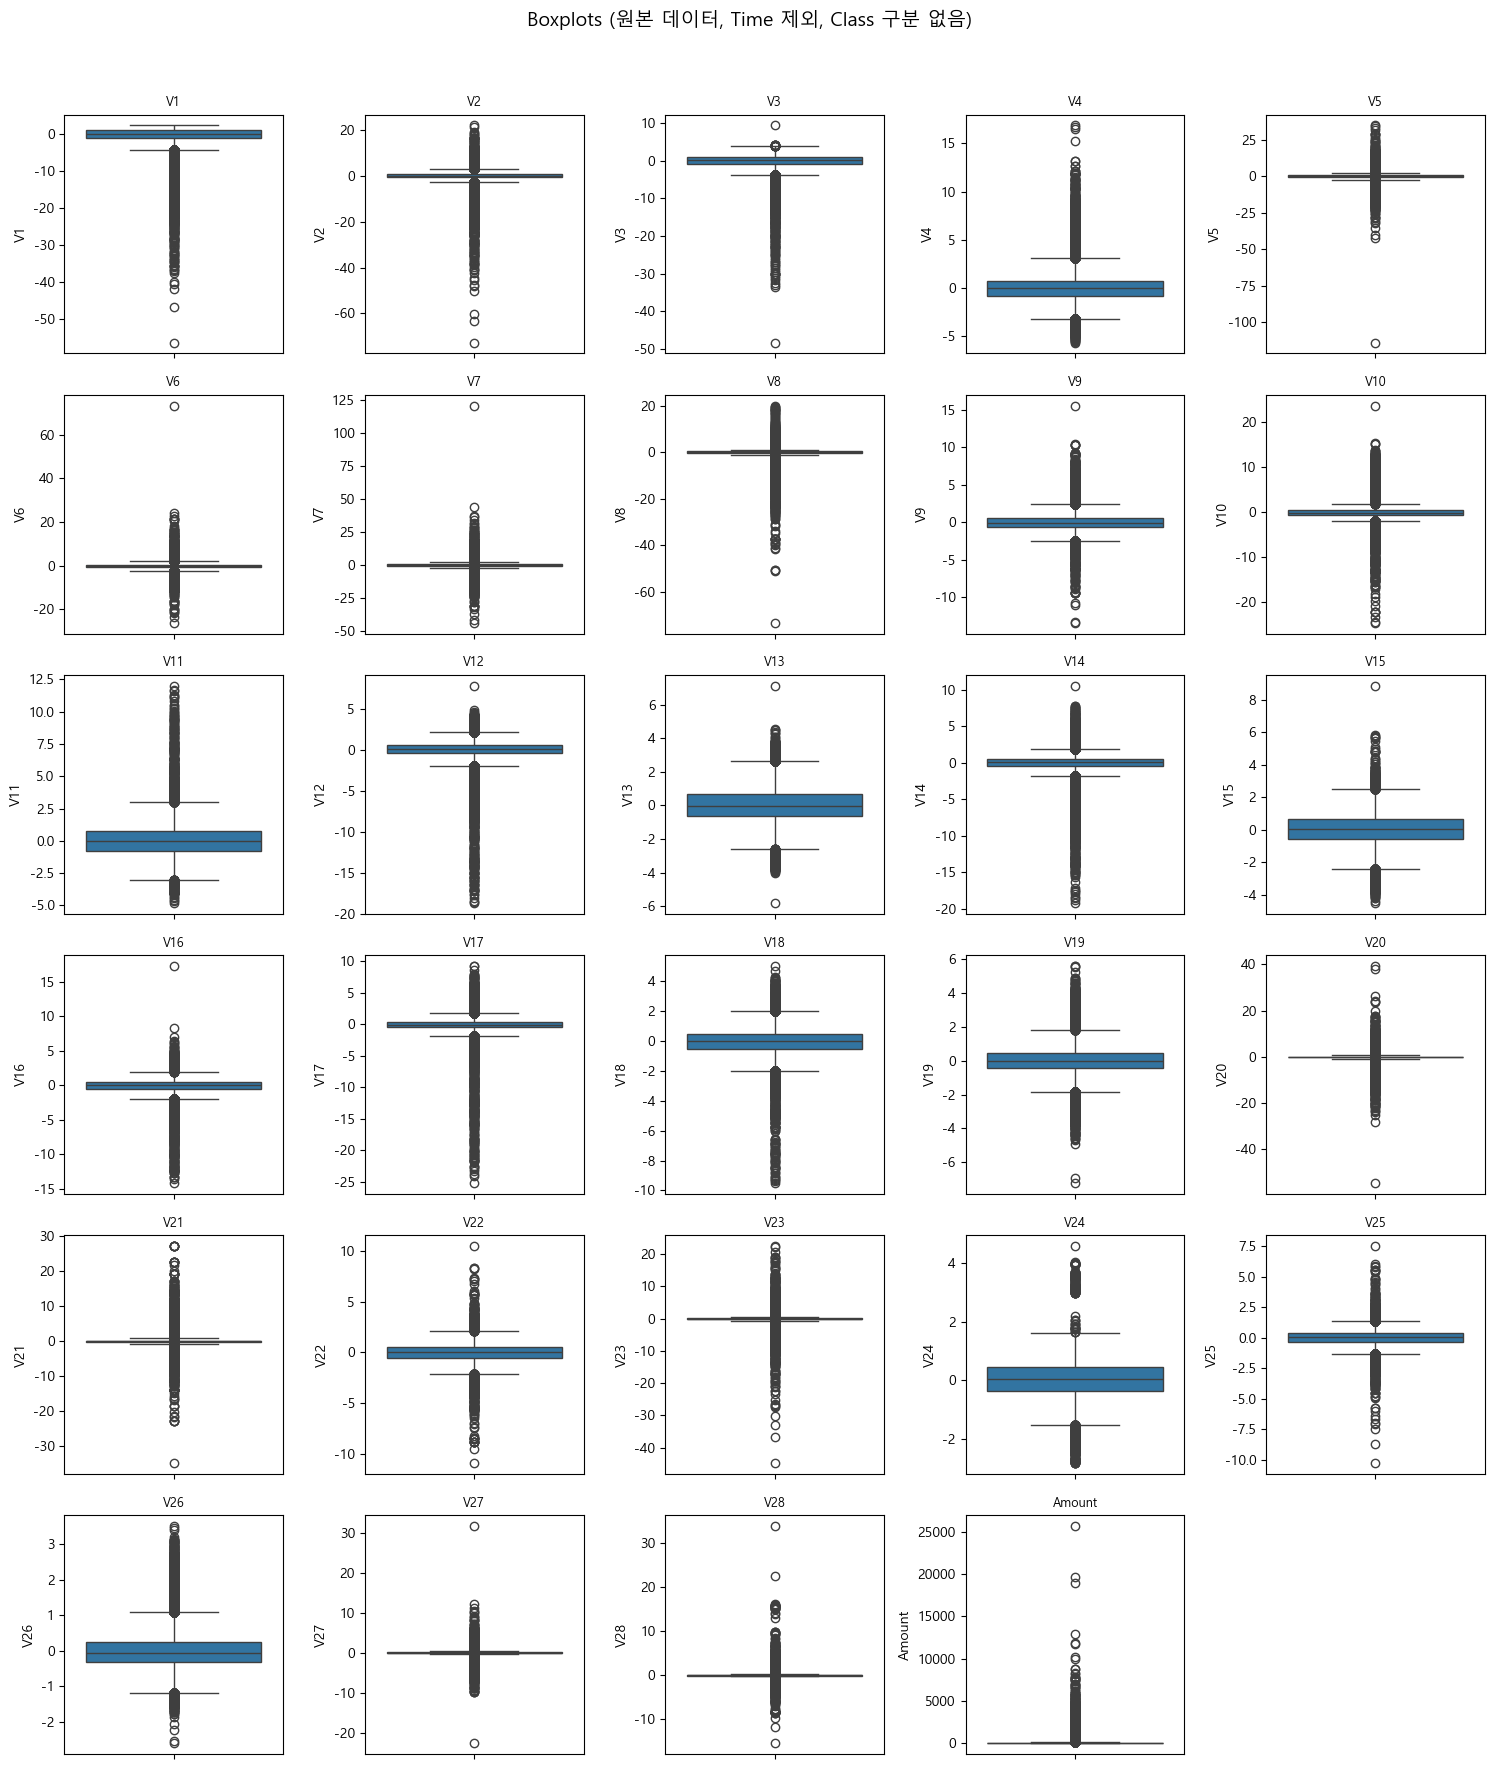

In [114]:
# 클래스 합친 버전 박스플롯 (원본 df 기준)
plot_box_grid_all_features(
    df_in=df,
    feature_cols=feature_cols_no_time,
    title='Boxplots (원본 데이터, Time 제외, Class 구분 없음)'
)

In [ ]:
def plot_scatter_grid_all_features(df_in, feature_cols, title,
                                   n_cols=5, sample_n=5000, random_state=42):

    """
    클래스 구분 없이, 각 피처에 대한 산점도 (x: index, y: feature value)
    너무 많으니 sample_n개로 샘플링해서 그림
    """
    # 시각화용 샘플링
    if len(df_in) > sample_n:
        df_plot = df_in.sample(n=sample_n, random_state=random_state)
    else:
        df_plot = df_in.copy()

    df_plot = df_plot.reset_index(drop=True)
    x_vals = np.arange(len(df_plot))

    n_rows = math.ceil(len(feature_cols) / n_cols)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 3, n_rows * 3)
    )
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        axes[i].scatter(x_vals, df_plot[col], s=5, alpha=0.5)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('index')
        axes[i].set_ylabel('value')

    # 남는 subplot 지우기
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


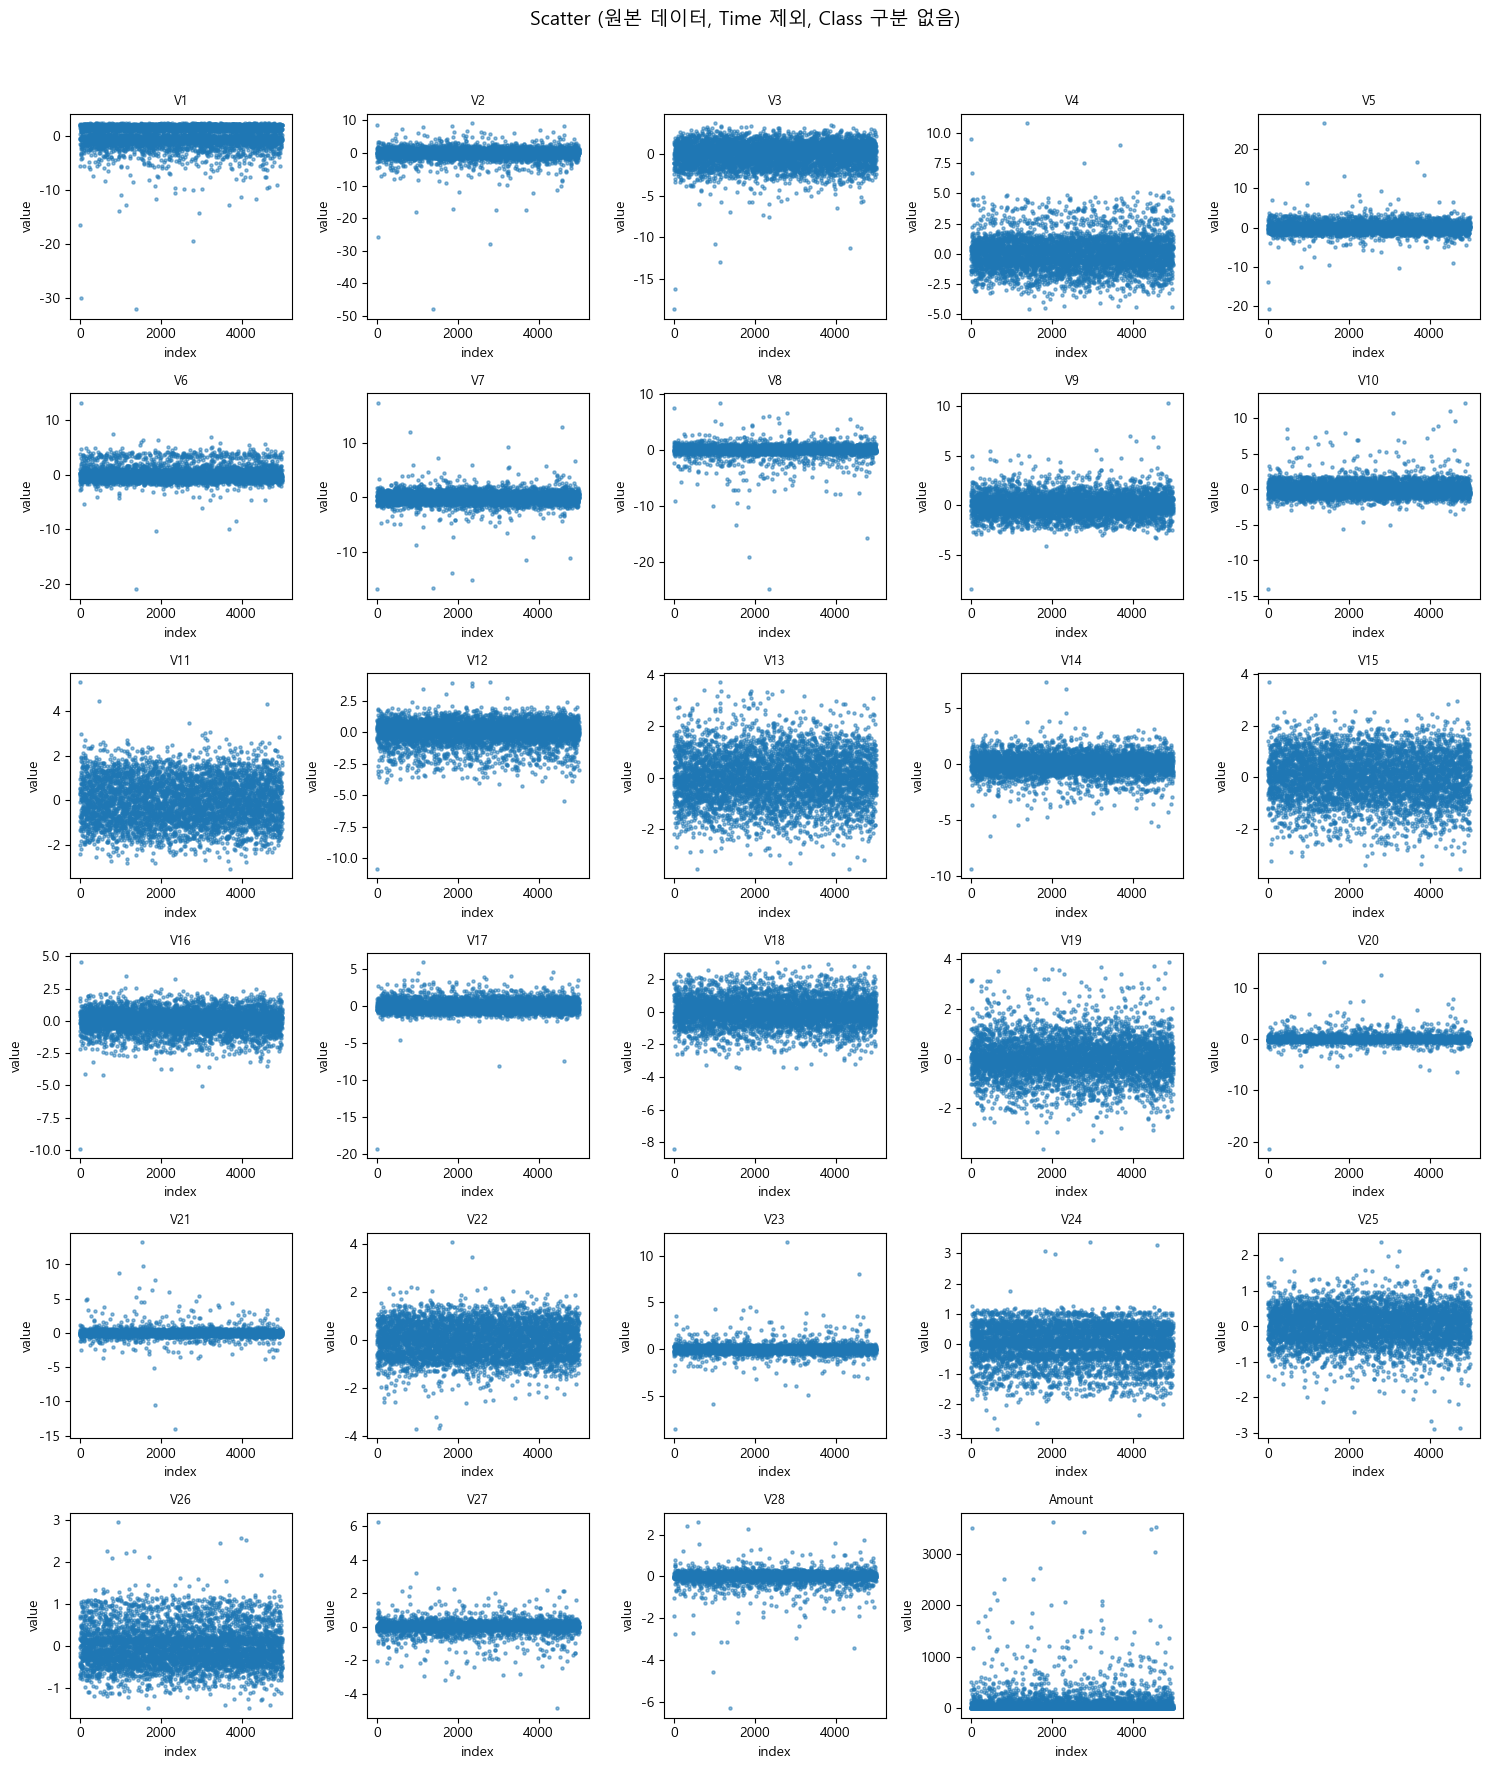

In [116]:
# Time 없는 버전 산점도 (Class 안 나눔)
plot_scatter_grid_all_features(
    df_in=df,
    feature_cols=feature_cols_no_time,
    title='Scatter (원본 데이터, Time 제외, Class 구분 없음)',
    n_cols=5,
    sample_n=5000
)

In [118]:
# 0) Time과 Class를 제외한 피처들
feature_cols_no_time = [
    c for c in df.columns
    if c not in ['Class', 'Time']
]

X_all = df[feature_cols_no_time].values
y_all = df['Class'].values

# 1) 공통 PCA 한 번만 fit
pca = PCA(n_components=2, random_state=42)
X_all_2d = pca.fit_transform(X_all)   # 공통 좌표 (PC1, PC2)

# 2) subset용 마스크
fraud_mask  = (y_all == 1)
normal_mask = ~fraud_mask

X_fraud_2d  = X_all_2d[fraud_mask]
X_normal_2d = X_all_2d[normal_mask]

# 3) 나중에 축 범위 고정용
x_min, x_max = X_all_2d[:, 0].min(), X_all_2d[:, 0].max()
y_min, y_max = X_all_2d[:, 1].min(), X_all_2d[:, 1].max()

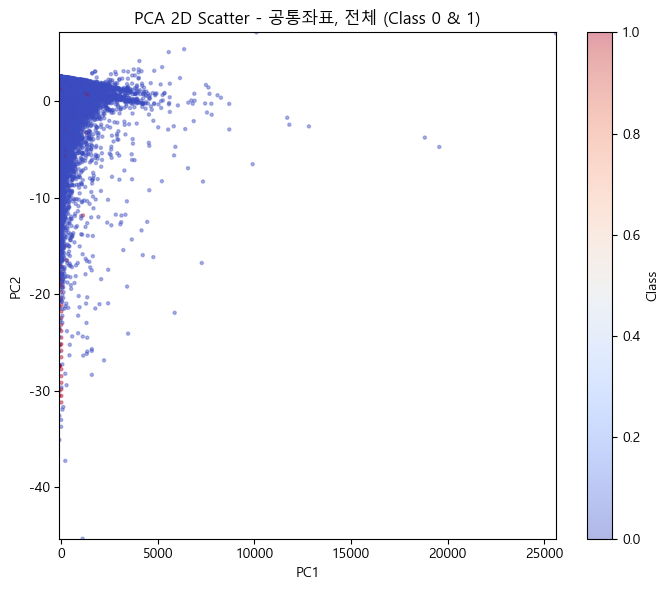

In [119]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_all_2d[:, 0], X_all_2d[:, 1],
    c=y_all,
    cmap='coolwarm',
    alpha=0.4,
    s=5
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 공통좌표, 전체 (Class 0 & 1)')
cbar = plt.colorbar(scatter)
cbar.set_label('Class')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

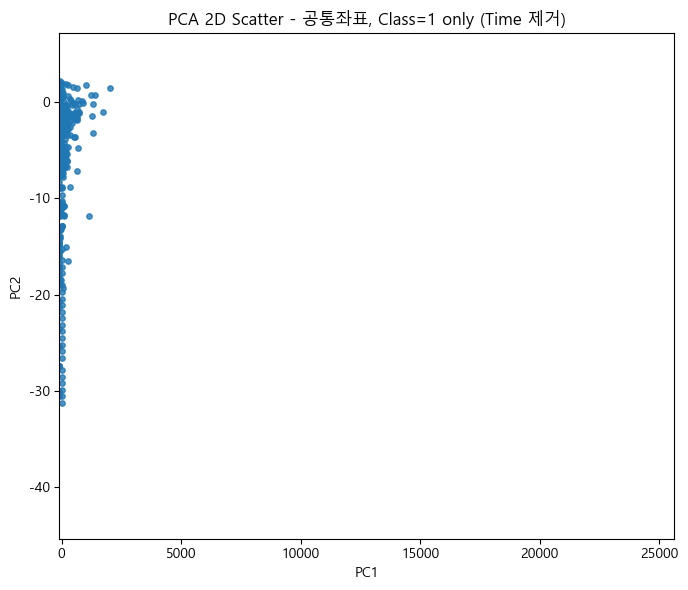

In [120]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_fraud_2d[:, 0], X_fraud_2d[:, 1],
    alpha=0.8,
    s=15
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 공통좌표, Class=1 only (Time 제거)')
# 전체와 비교 가능하게 축 고정
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

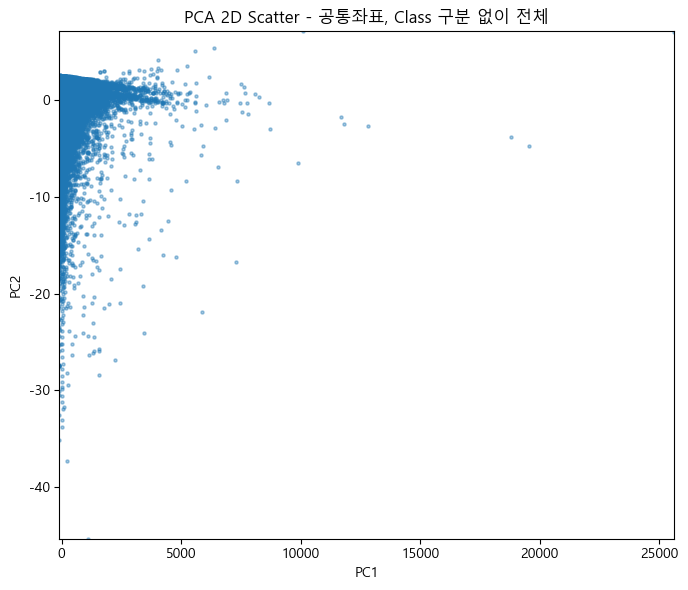

In [121]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_all_2d[:, 0], X_all_2d[:, 1],
    alpha=0.4,
    s=5
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Scatter - 공통좌표, Class 구분 없이 전체')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()